In [1]:
#Set path to parent directory
import sys
sys.path.append("..")
import numpy as np, torch
import scipy.stats as st
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import itertools
from decompTCR.tools._basis_decomposition.run_batch import compute_basis_decomposition, _plot_basis, get_basis
from decompTCR.tools._basis_decomposition.inference  import InferenceMode
from pyro.infer import Predictive, TraceEnum_ELBO
import matplotlib.pyplot as plt
import matplotlib
import scanpy as sc
import seaborn as sns
import pandas as pd
import pickle
import os
from sklearn.preprocessing import MaxAbsScaler, StandardScaler, MinMaxScaler
import datetime
from umap import UMAP

import pyro

from sklearn.neighbors import kneighbors_graph
from sknetwork.clustering import Louvain
from umap import UMAP
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score



from decompTCR.tools._basis_decomposition.inference import get_inference_guide
from decompTCR.tools._basis_decomposition.model_batch import BasisDecomposition, BasisDecomposition_Evaluate
from pyro.infer import Predictive, SVI, Trace_ELBO, TraceTMC_ELBO

from kneed import KneeLocator
import kneed
import statsmodels.api as sm
from matplotlib.colors import LinearSegmentedColormap

from utils import display_cat, clear_val_params, summary, process_data, find_sequence_rows_regex, clustermap


## Load Data and Preprocessing
Data file is expected to be a file that is n x p matrix, where there are n clones across all patients and p features including
- frequency (templates/total templates, per patient and per timepoint)
- templates (# of T cells per timepoint and patient)
- timepoint 
- tag   (Unique identifier for clone, combination of cdr3_amino acid, v_resolved, and j_resolved)
- PatientID
- cdr3_amino_acid (Amino acid sequence of cdr3 region)
- v_resolved
- j_resolved
- ifexpanded  
- allo      (True if alloreactive)
- cell_type (Can either be CD4, CD8 or both)
- GVHD_GRADE_1
- GVHD_GRADE_2
- GVHD_GRADE_3
- Onset (Onset in Days)
- Age_R
- DonorType
- PTCy (True if recieved PTCy)
- Sex
- mapped Whether or not cells are mapped from single cell
- Tissue_Location
- Migration_all 
- leiden_0.5 (Clustering from single cell analysis)
- clone_encoding
- time_encoding

In [2]:
#Load Data
data = pd.read_csv("../input_data/AllClones.csv", low_memory=False) #Downlaod from Google Drive
meta_data = ["ifexpanded", "allo", "cell_type", "GVHD_GRADE_1", "GVHD_GRADE_2", "GVHD_GRADE_3", "Onset", "Age_R", "DonorType", "PTCy", "Sex", "HLA_mis", "Conditioning", "mapped", "Tissue_Location", "Migration_all", "leiden_0.5"]

clone_pattern_dense_filtered, data, filter_idx = process_data(data, meta_data, last_timepoint = 180, n_filter = 2)

Converting timepoints to numeric values


/Users/pressm/Documents/AziziLab/GVHD_Reproducibility/DecompTCR/pipelines/../utils.py:276: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  indices = torch.tensor([data["clone_encoding"].values, data["time_encoding"].values], dtype=torch.int64)


In [3]:
#Change Unclassified/Severe Patient To Severe
data.loc[data["GVHD_GRADE_1"] == "Unclassified/Severe", "GVHD_GRADE_1"] = "Severe"
data.loc[data["GVHD_GRADE_1"] == "Unclassified/Severe", "GVHD_GRADE_2"] = "Severe"

In [4]:
#Filter data for only alloreactive clones
data_down = data.drop(["frequency", "time_encoding", "timepoint"], axis = 1)
data_down = data_down.drop_duplicates(subset=["clone_encoding", "tag"])
data_down = data_down.sort_values(by = "clone_encoding")
data_down = data_down.reset_index(drop = True)

data_filt = data_down[filter_idx.numpy()]

data_filt_na = data_filt[data_filt["allo"] == False].reset_index(drop = True).reset_index()
data_filt_a = data_filt[data_filt["allo"] == True].reset_index(drop = True).reset_index()


clone_patterns_na = clone_pattern_dense_filtered[(data_filt["allo"]==False).values]
clone_patterns_a = clone_pattern_dense_filtered[(data_filt["allo"]==True).values]

data_filt_a["GVHD_GRADE_1"] = pd.Categorical(data_filt_a["GVHD_GRADE_1"], categories = ["No", "Mild", "Severe"])

In [5]:
#Add padding to the clone patterns for fitting the model. You can increase or decrease the padding based on your data.
times_padded = np.linspace(-1,1, clone_pattern_dense_filtered.shape[1]) #Create a vector with the proper length of time. Time is normalized in this case from -1,1 and length of 181
nan_padding = torch.full((clone_pattern_dense_filtered.shape[0],10), fill_value = torch.nan )
clone_patterns_padded = torch.cat((clone_pattern_dense_filtered, nan_padding), dim=1)

nan_padding_allo = torch.full((clone_patterns_a.shape[0],10), fill_value = torch.nan )
clone_patterns_padded_allo = torch.cat((clone_patterns_a, nan_padding_allo), dim=1)

nan_padding_nonallo = torch.full((clone_patterns_na.shape[0],10), fill_value = torch.nan )
clone_patterns_padded_nonallo = torch.cat((clone_patterns_na, nan_padding_nonallo), dim=1)

In [6]:
idxs = np.argsort(times_padded) #Ensure that the columns are sorted by time
times_padded = times_padded[idxs]
clone_patterns_padded = clone_patterns_padded[:,idxs]
clone_patterns_padded_allo = clone_patterns_padded_allo[:,idxs]
clone_patterns_padded_nonallo = clone_patterns_padded_nonallo[:,idxs]

In [7]:
#Train Test Split for nonalloreactive clones
train_na_idx, val_na_idx = train_test_split(np.arange(len(clone_patterns_padded_nonallo)), test_size = .2)
clone_patterns_padded_nonallo_train = clone_patterns_padded_nonallo[train_na_idx, :]
clone_patterns_padded_nonallo_val = clone_patterns_padded_nonallo[val_na_idx, :]


In [8]:
#Train Test Split for alloreactive clones

train_a_idx, val_a_idx = train_test_split(np.arange(clone_patterns_padded_allo.shape[0]), test_size = 0.1)
clone_patterns_padded_allo_train = clone_patterns_padded_allo[train_a_idx,:]
clone_patterns_padded_allo_val = clone_patterns_padded_allo[val_a_idx,:]

## Train and Fit the Model
DO NOT RUN THE TWO BLOCKS BELOW IF YOU WOULD LIKE TO RECREATE THE FIGURES EXACTLY

In [9]:
#Set Parameters
n_basis = 15
n_iter = 100
show_basis = False
lr = 1e-2
beta_prior = 1.1
weight_decay = 1e-7
inverse_length_scale = 5

### Uncomment Below to Run Basis

In [10]:



# trajectory_model_a, guide_a, times_a, samples_a, clone_scales_a, losses_a, rel_loss_a, val_loss_a = compute_basis_decomposition(
# clone_patterns_padded_allo_train.numpy(),#clone_patterns_masked,#clone_patterns_padded,
# InferenceMode.POINT_ESTIMATE, #GAUSSIAN_BETA_ONLY
# n_basis=n_basis,
# n_iter=n_iter,
# batch_size=None,
# #show_basis=show_basis,
# lr=lr,
# beta_prior=beta_prior,
# weight_decay = weight_decay,
# inverse_length_scale = inverse_length_scale,
# seed=3,
# normalized_mode=True,
# times = times_padded,
# plot_every_k_epochs=100,
# clone_patterns_val= clone_patterns_padded_allo_val.numpy()
# ) 



### Uncomment to save run

In [11]:
# specific_datetime_string = "_2024_04_29_10_34_01"

# # If you want to generate it from a specific date:
# # specific_date = datetime(2024, 4, 29, 10, 34, 1) # Year, Month, Day, Hour, Minute, Second
# # specific_datetime_string = specific_date.strftime("_%Y_%m_%d_%H_%M_%S")


# save_dir = "../input_data/basis_decomp_saved_runs/"
# os.makedirs(save_dir, exist_ok=True) # Ensure directory exists

# # Create a single dictionary to hold all relevant data
# # Use .state_dict() for models/guides
# checkpoint = {
#     'trajectory_model_a_obj_params': trajectory_model_a.__dict__,
#     'guide_a_state_dict': guide_a.state_dict(),
#     'times_a': times_a,
#     'samples_a': samples_a,
#     'clone_scales_a': clone_scales_a,
#     'losses_a': losses_a,
#     'rel_loss_a': rel_loss_a,
#     'val_loss_a': val_loss_a,
#     'train_a_idx': train_a_idx,
#     'val_a_idx': val_a_idx,
#     'basis_a': basis_a,
#     '_last_basis': trajectory_model_a._last_basis, # Assuming _last_basis is a relevant attribute
#     # Add any other metadata you want to save, e.g.:
#     'training_epochs': 100, # Example hyperparameter
#     'learning_rate': 0.001, # Example hyperparameter
#     'run_timestamp': specific_datetime_string # Store the used timestamp
# }

# # Save the entire checkpoint dictionary to a single .pth file
# # Use the specific_datetime_string in the filename
# save_path = os.path.join(save_dir, f"{specific_datetime_string}_full_run_checkpoint.pth")
# torch.save(checkpoint, save_path)

# print(f"All data saved to: {save_path}")

### To Load fitted model uncomment below

In [12]:

load_path = "../input_data/basis_decomp_saved_runs/_2024_04_29_10_34_01_full_run_checkpoint.pth"

# Load the entire checkpoint dictionary
loaded_checkpoint = torch.load(load_path, weights_only=False)

print(f"Loading data from: {load_path}")

# # Re-instantiate models and load their state_dicts
trajectory_model_a = BasisDecomposition(loaded_checkpoint['trajectory_model_a_obj_params']["K"],n_clones = loaded_checkpoint['trajectory_model_a_obj_params']["n_clones"], batch_size=loaded_checkpoint['trajectory_model_a_obj_params']["batch_size"]) # Instantiate your actual model class


trajectory_model_a._last_basis = loaded_checkpoint['_last_basis'] # Assuming _last_basis is a relevant attribute



# Extract all other data
# trajectory_model_a = loaded_checkpoint['trajectory_model_a_obj_params']
times_a = loaded_checkpoint['times_a']
samples_a = loaded_checkpoint['samples_a']
clone_scales_a = loaded_checkpoint['clone_scales_a']
losses_a = loaded_checkpoint['losses_a']
rel_loss_a = loaded_checkpoint['rel_loss_a']
val_loss_a = loaded_checkpoint['val_loss_a']
train_a_idx = loaded_checkpoint['train_a_idx']
val_a_idx = loaded_checkpoint['val_a_idx']
basis_a = loaded_checkpoint['basis_a']

# Your original code after loading (assuming clone_patterns_padded_allo is available)
clone_patterns_padded_allo_train = clone_patterns_padded_allo[train_a_idx,:]
clone_patterns_padded_allo_val = clone_patterns_padded_allo[val_a_idx,:]

Loading data from: ../input_data/basis_decomp_saved_runs/_2024_04_29_10_34_01_full_run_checkpoint.pth


In [13]:
#This code is used to recover clone_scales that were accidentally multiplied with clone_scales as an outerproduct giving an matrix of nxn for clone_scales

# reverse_vec = torch.ones((clone_patterns_padded_allo_train.shape[0],1)) / clone_patterns_padded_allo_train.nanmean(axis = -1, keepdim = True, dtype = torch.float64)
# clone_mean = clone_patterns_padded_allo_train.nanmean(axis = -1, keepdim = True, dtype = torch.float64).numpy()
# clone_scales_a = clone_scales_a.squeeze()
# recoverd_clone_scales = ((clone_scales_a @ reverse_vec.numpy())/len(clone_scales_a)*clone_mean)
# print(recoverd_clone_scales)
# torch.save(recoverd_clone_scales, "../input_data/basis_decomp_saved_runs/_2024_04_29_10_34_01gene_scales_a_2.pth")



## Validating Model Fit and Post-Processing

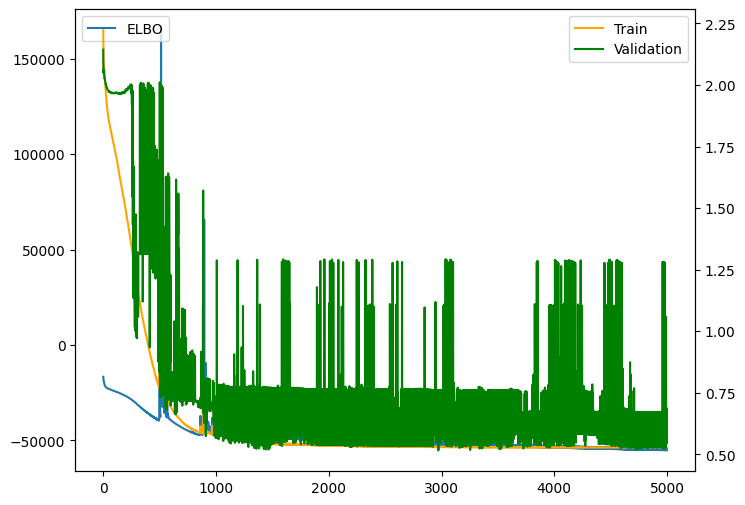

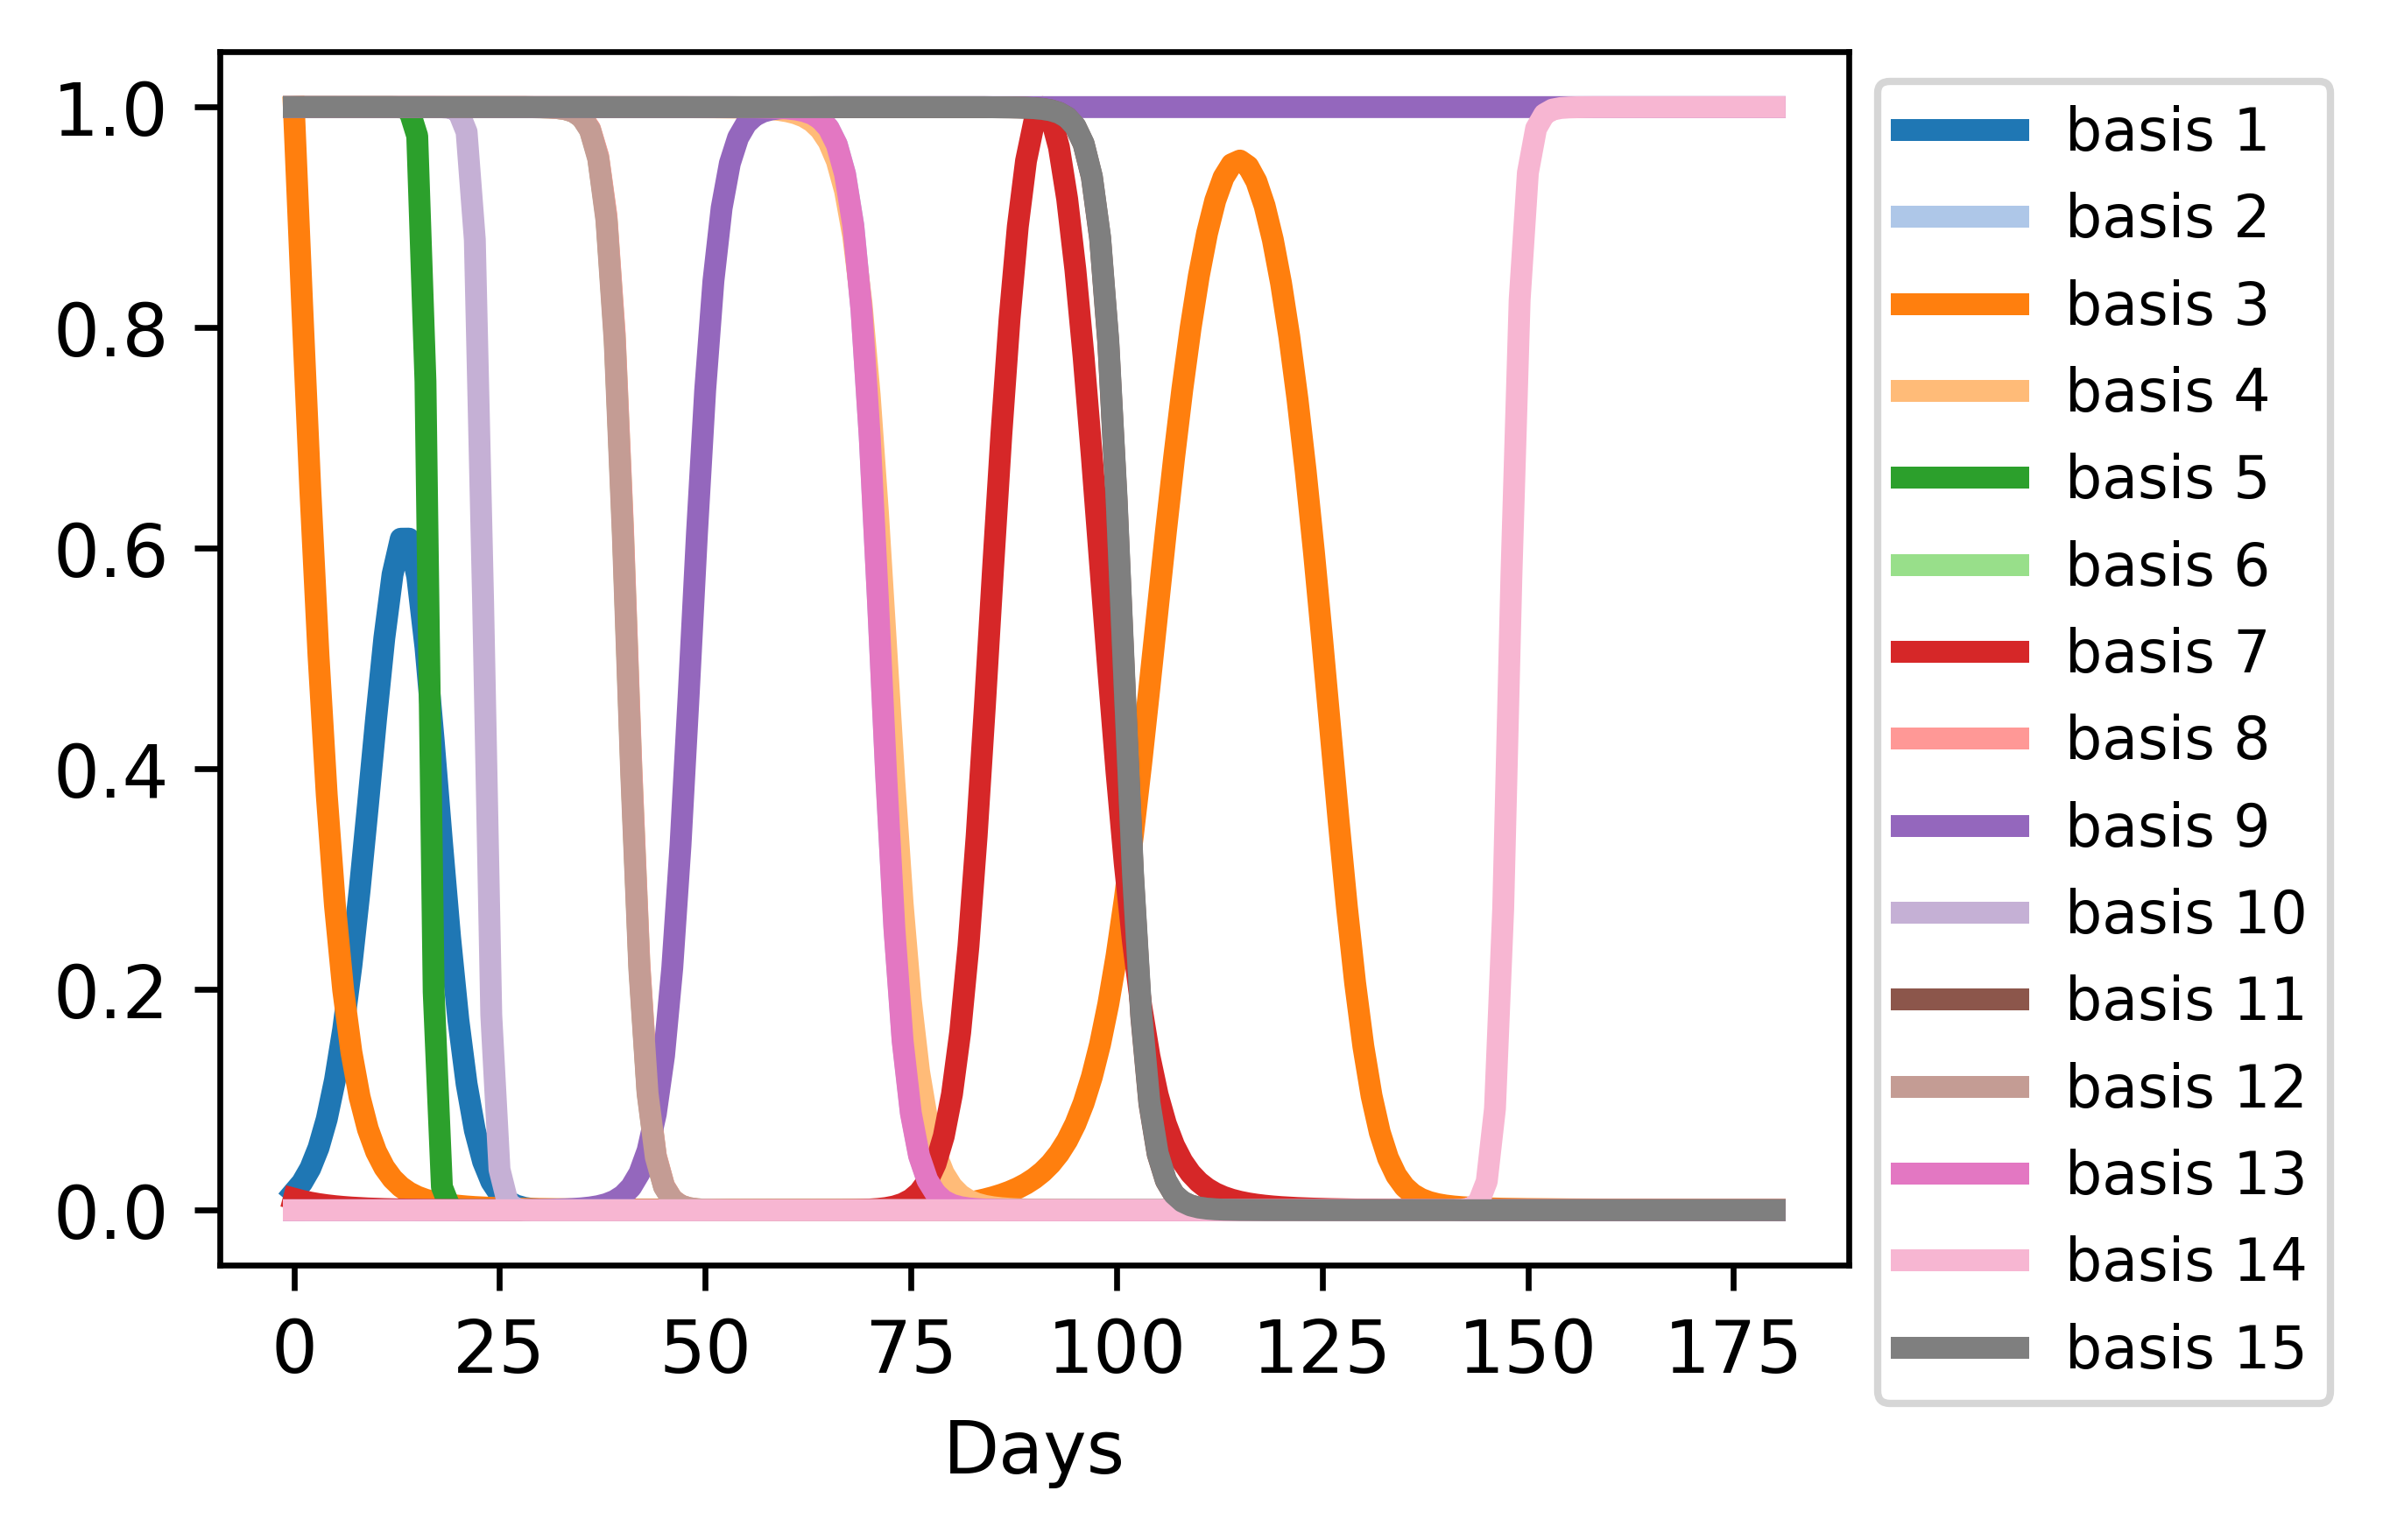

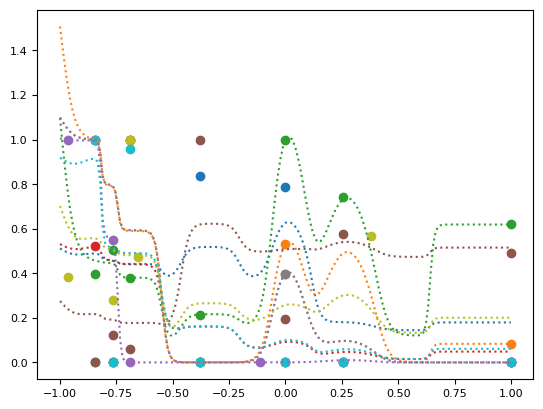

In [14]:
fig, ax = plt.subplots(1,1, figsize = (8,6))
ax.plot(losses_a)
ax2 = ax.twinx()
ax2.plot(rel_loss_a, color = "orange")
ax2.plot(val_loss_a, color = "green")
ax.legend(["ELBO"], loc = "upper left")
ax2.legend(["Train", "Validation"])

#UNCOMMMENT BELOW FOR NEW RUNS
# basis_a = get_basis(trajectory_model_a, guide_a, clone_patterns_padded_allo_train.numpy(), times_a)
# torch.save(basis_a, "../input_data/basis_decomp_saved_runs/"+formatted_datetime+"basis_a.pth")


colors = sns.color_palette("tab20", 20)


#Display the training and validation curve alongside ELBO. Also plot Basis and some example reconstruction
fig, ax = plt.subplots(1,1, figsize=(4,3), dpi = 600)
plt.rcParams.update({'font.size': 8})
ax = _plot_basis(basis_a, colors)
plt.xlabel("Days")
plt.legend(bbox_to_anchor=(1,1),loc = "upper left")
plt.show()


reconstruction = samples_a['_RETURN']['mean']
original = samples_a['obs']['mean']

m = 10
palette = sns.color_palette(n_colors=m)
for i in range(m):
    idx = np.random.randint(0,len(clone_patterns_padded_allo_train))
    plt.scatter(times_padded, clone_patterns_padded_allo_train[idx,:].detach().numpy(), color = palette[i])
    plt.plot(times_padded, reconstruction.numpy()[idx,:], ls = ':', color = palette[i])
plt.show()

To evaluate the model fit we freeze the patterns that we have learned and learn the weights for our validation data.

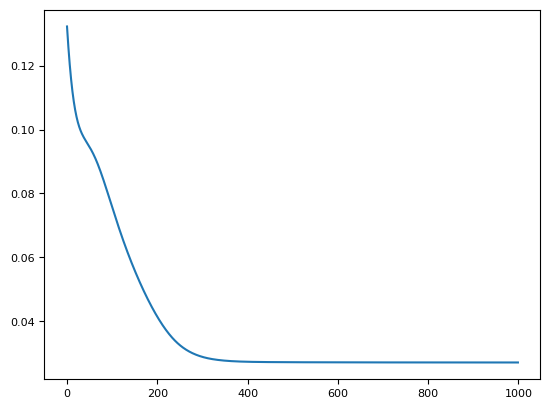

In [15]:
clear_val_params()
#Fit Validation Samples

adam = pyro.optim.ClippedAdam({"lr": .01})#Adam({"lr": lr})
elbo = Trace_ELBO()
    
model_val = BasisDecomposition_Evaluate(
            trajectory_model_a._last_basis.detach(),#torch.Tensor(np.array(my_basis).T),
            n_clones = clone_patterns_padded_allo_val.shape[0],
            beta_prior=beta_prior,
            normalized_mode = True
            
        )
guide_val = get_inference_guide(model_val, InferenceMode.POINT_ESTIMATE)
svi_val = SVI(model_val, guide_val, adam, loss=elbo)
val_loss = []
loss_val = 0
for _ in range(1000):
    loss_val = svi_val.step(torch.FloatTensor(times_padded), torch.FloatTensor(clone_patterns_padded_allo_val.numpy()))
    reconstruction_val = ((model_val._last_patterns - clone_patterns_padded_allo_val) ** 2).nanmean().item()
    val_loss.append(reconstruction_val)


plt.plot(val_loss)


samples_val = []
predictive = Predictive(
        model_val, guide=guide_val, num_samples=10, return_sites=("beta_val","_RETURN",  "obs_val")
    )
samples_val = predictive(times_a, clone_patterns_padded_allo_val)

clone_scales_val = model_val.gene_scales 
samples_val = summary(samples_val)


Now that we know that the validation samples are fitted with the given fixed basis functions we can display their reconstruction.

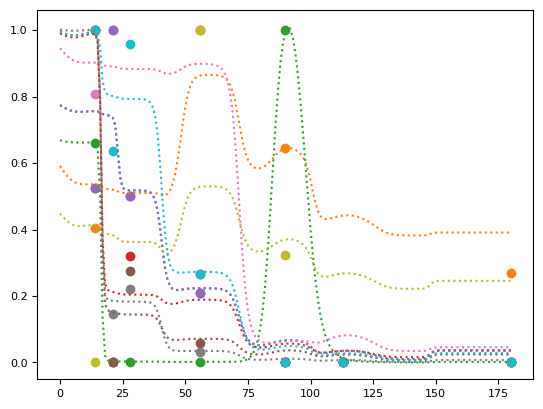

In [16]:
reconstruction_val = samples_val["beta_val"]["mean"].squeeze() @ basis_a.T * clone_scales_val.detach().numpy()
#Show reconstruction on validation

m = 10
palette = sns.color_palette(n_colors=m)

for i in range(m):
    idx = np.random.randint(0,len(clone_patterns_padded_allo_val))
    plt.scatter(np.arange(0,181), clone_patterns_padded_allo_val[idx,:].detach().numpy(), color = palette[i])
    plt.plot(np.arange(0,181), reconstruction_val.numpy()[idx,:], ls = ':', color = palette[i])
plt.show()

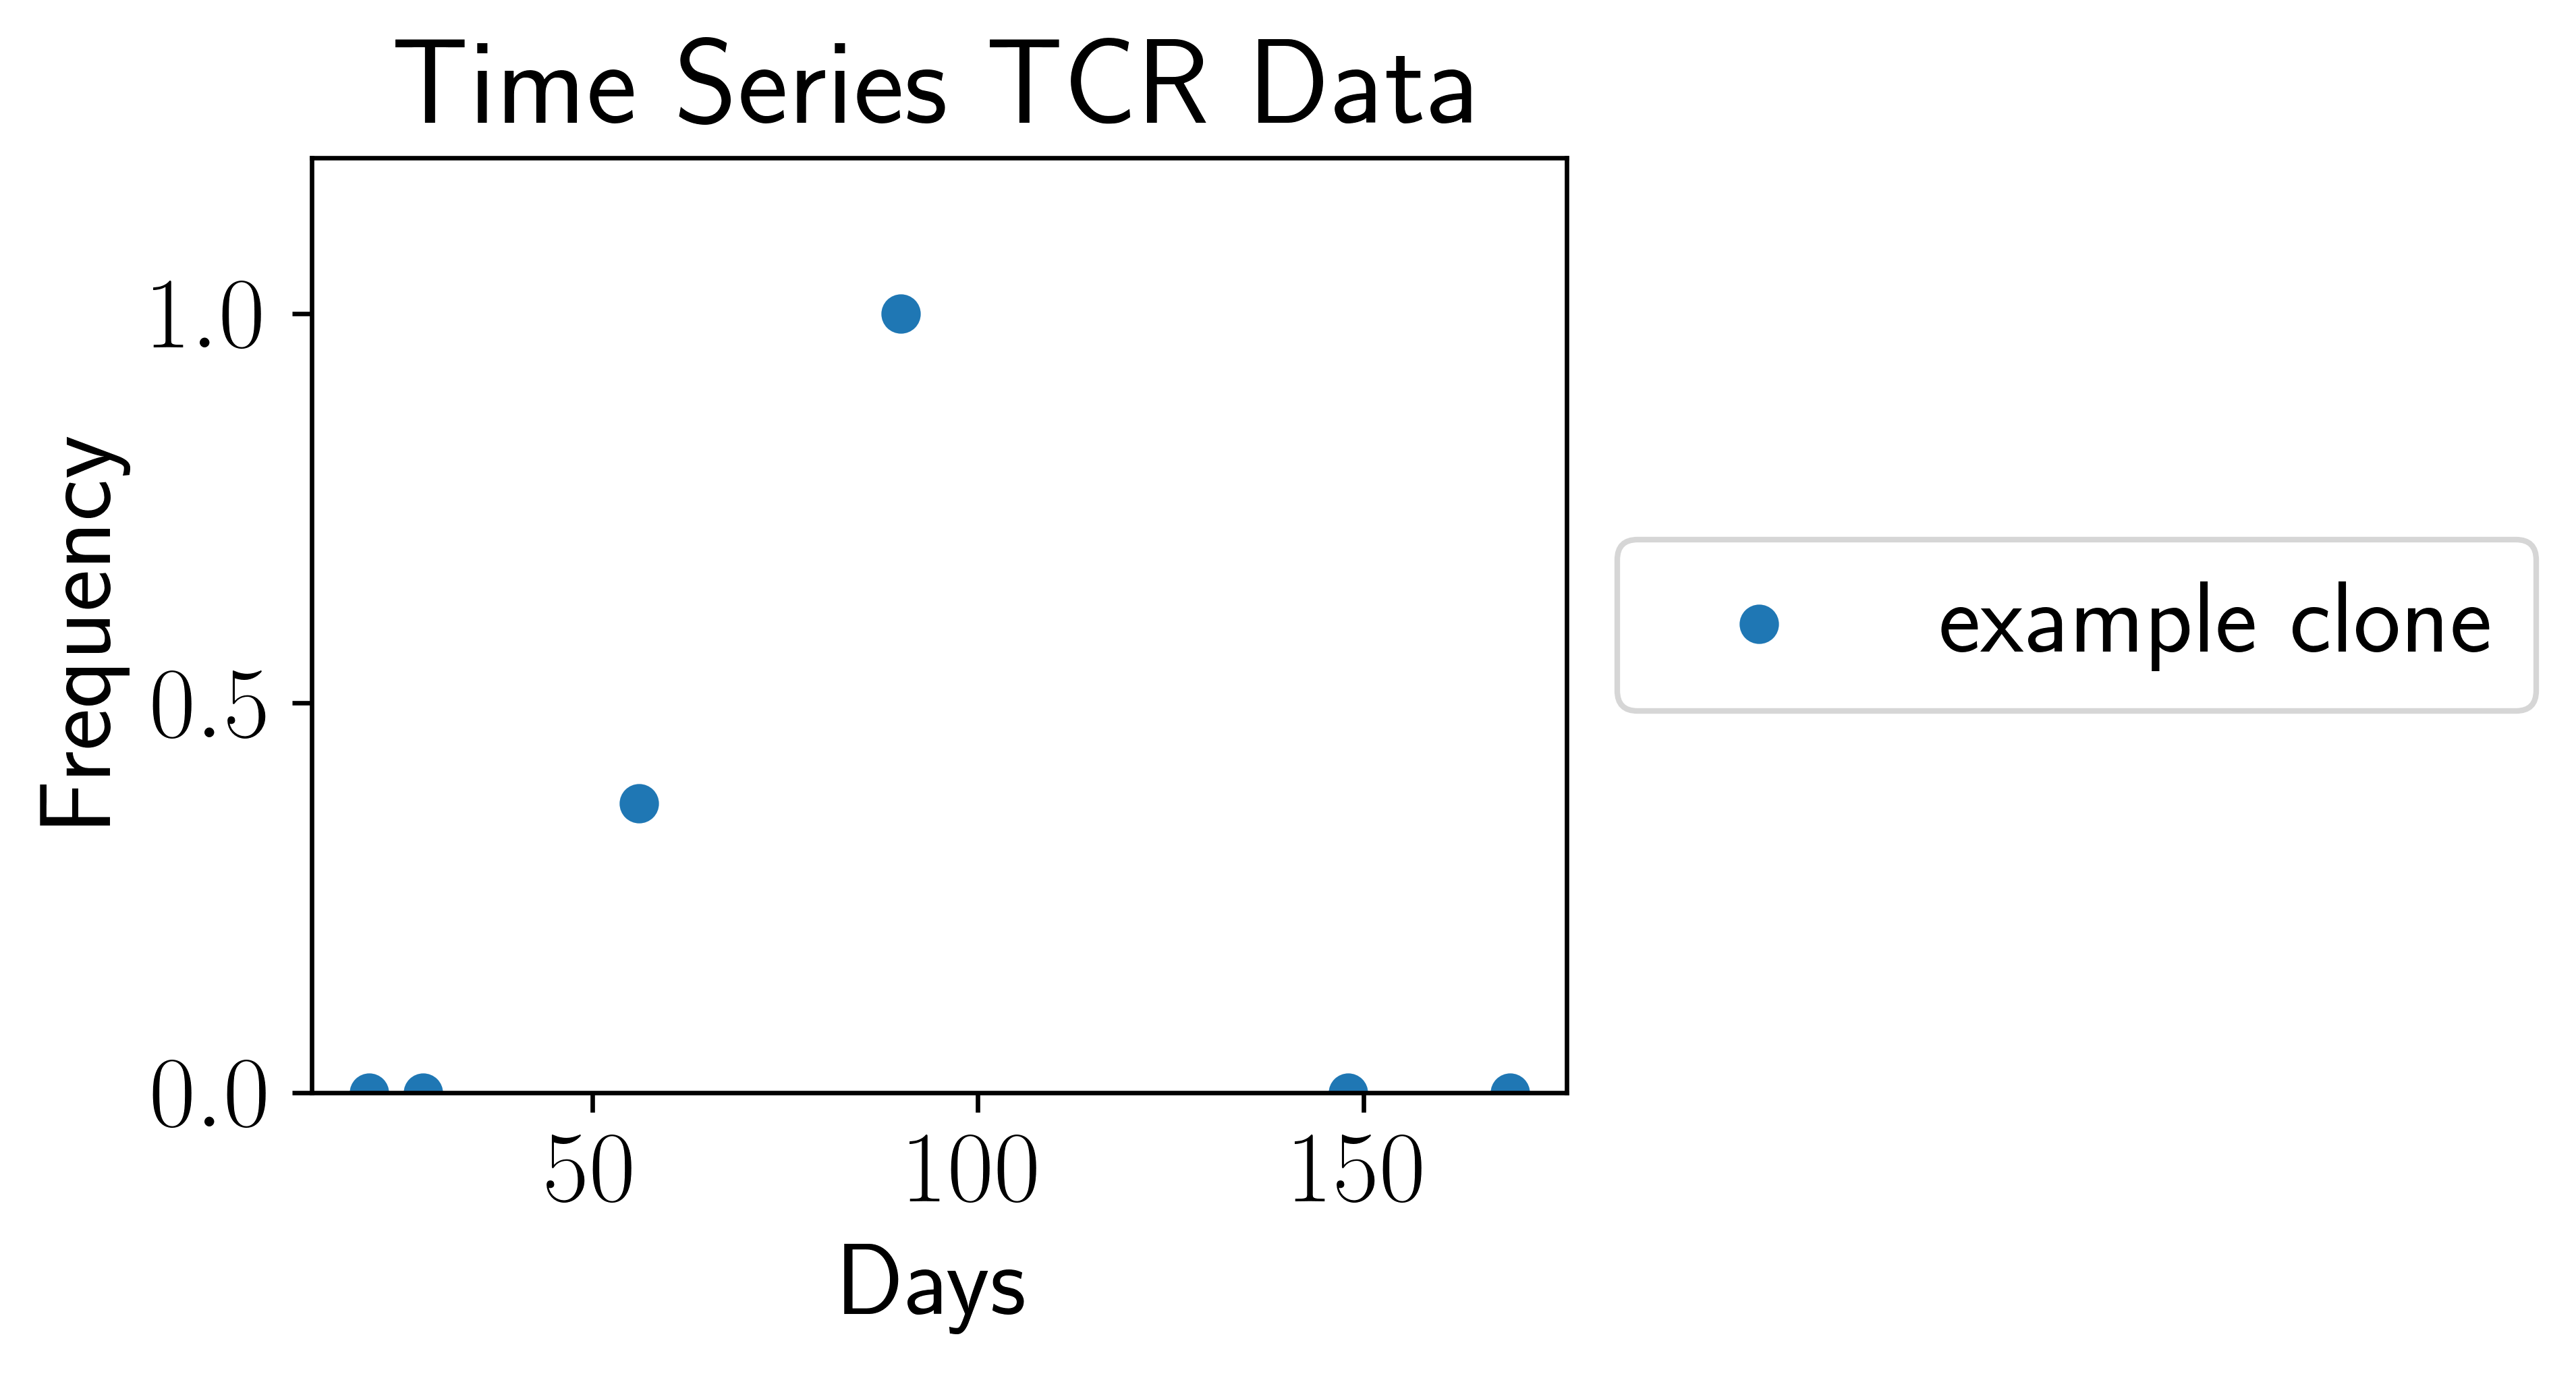

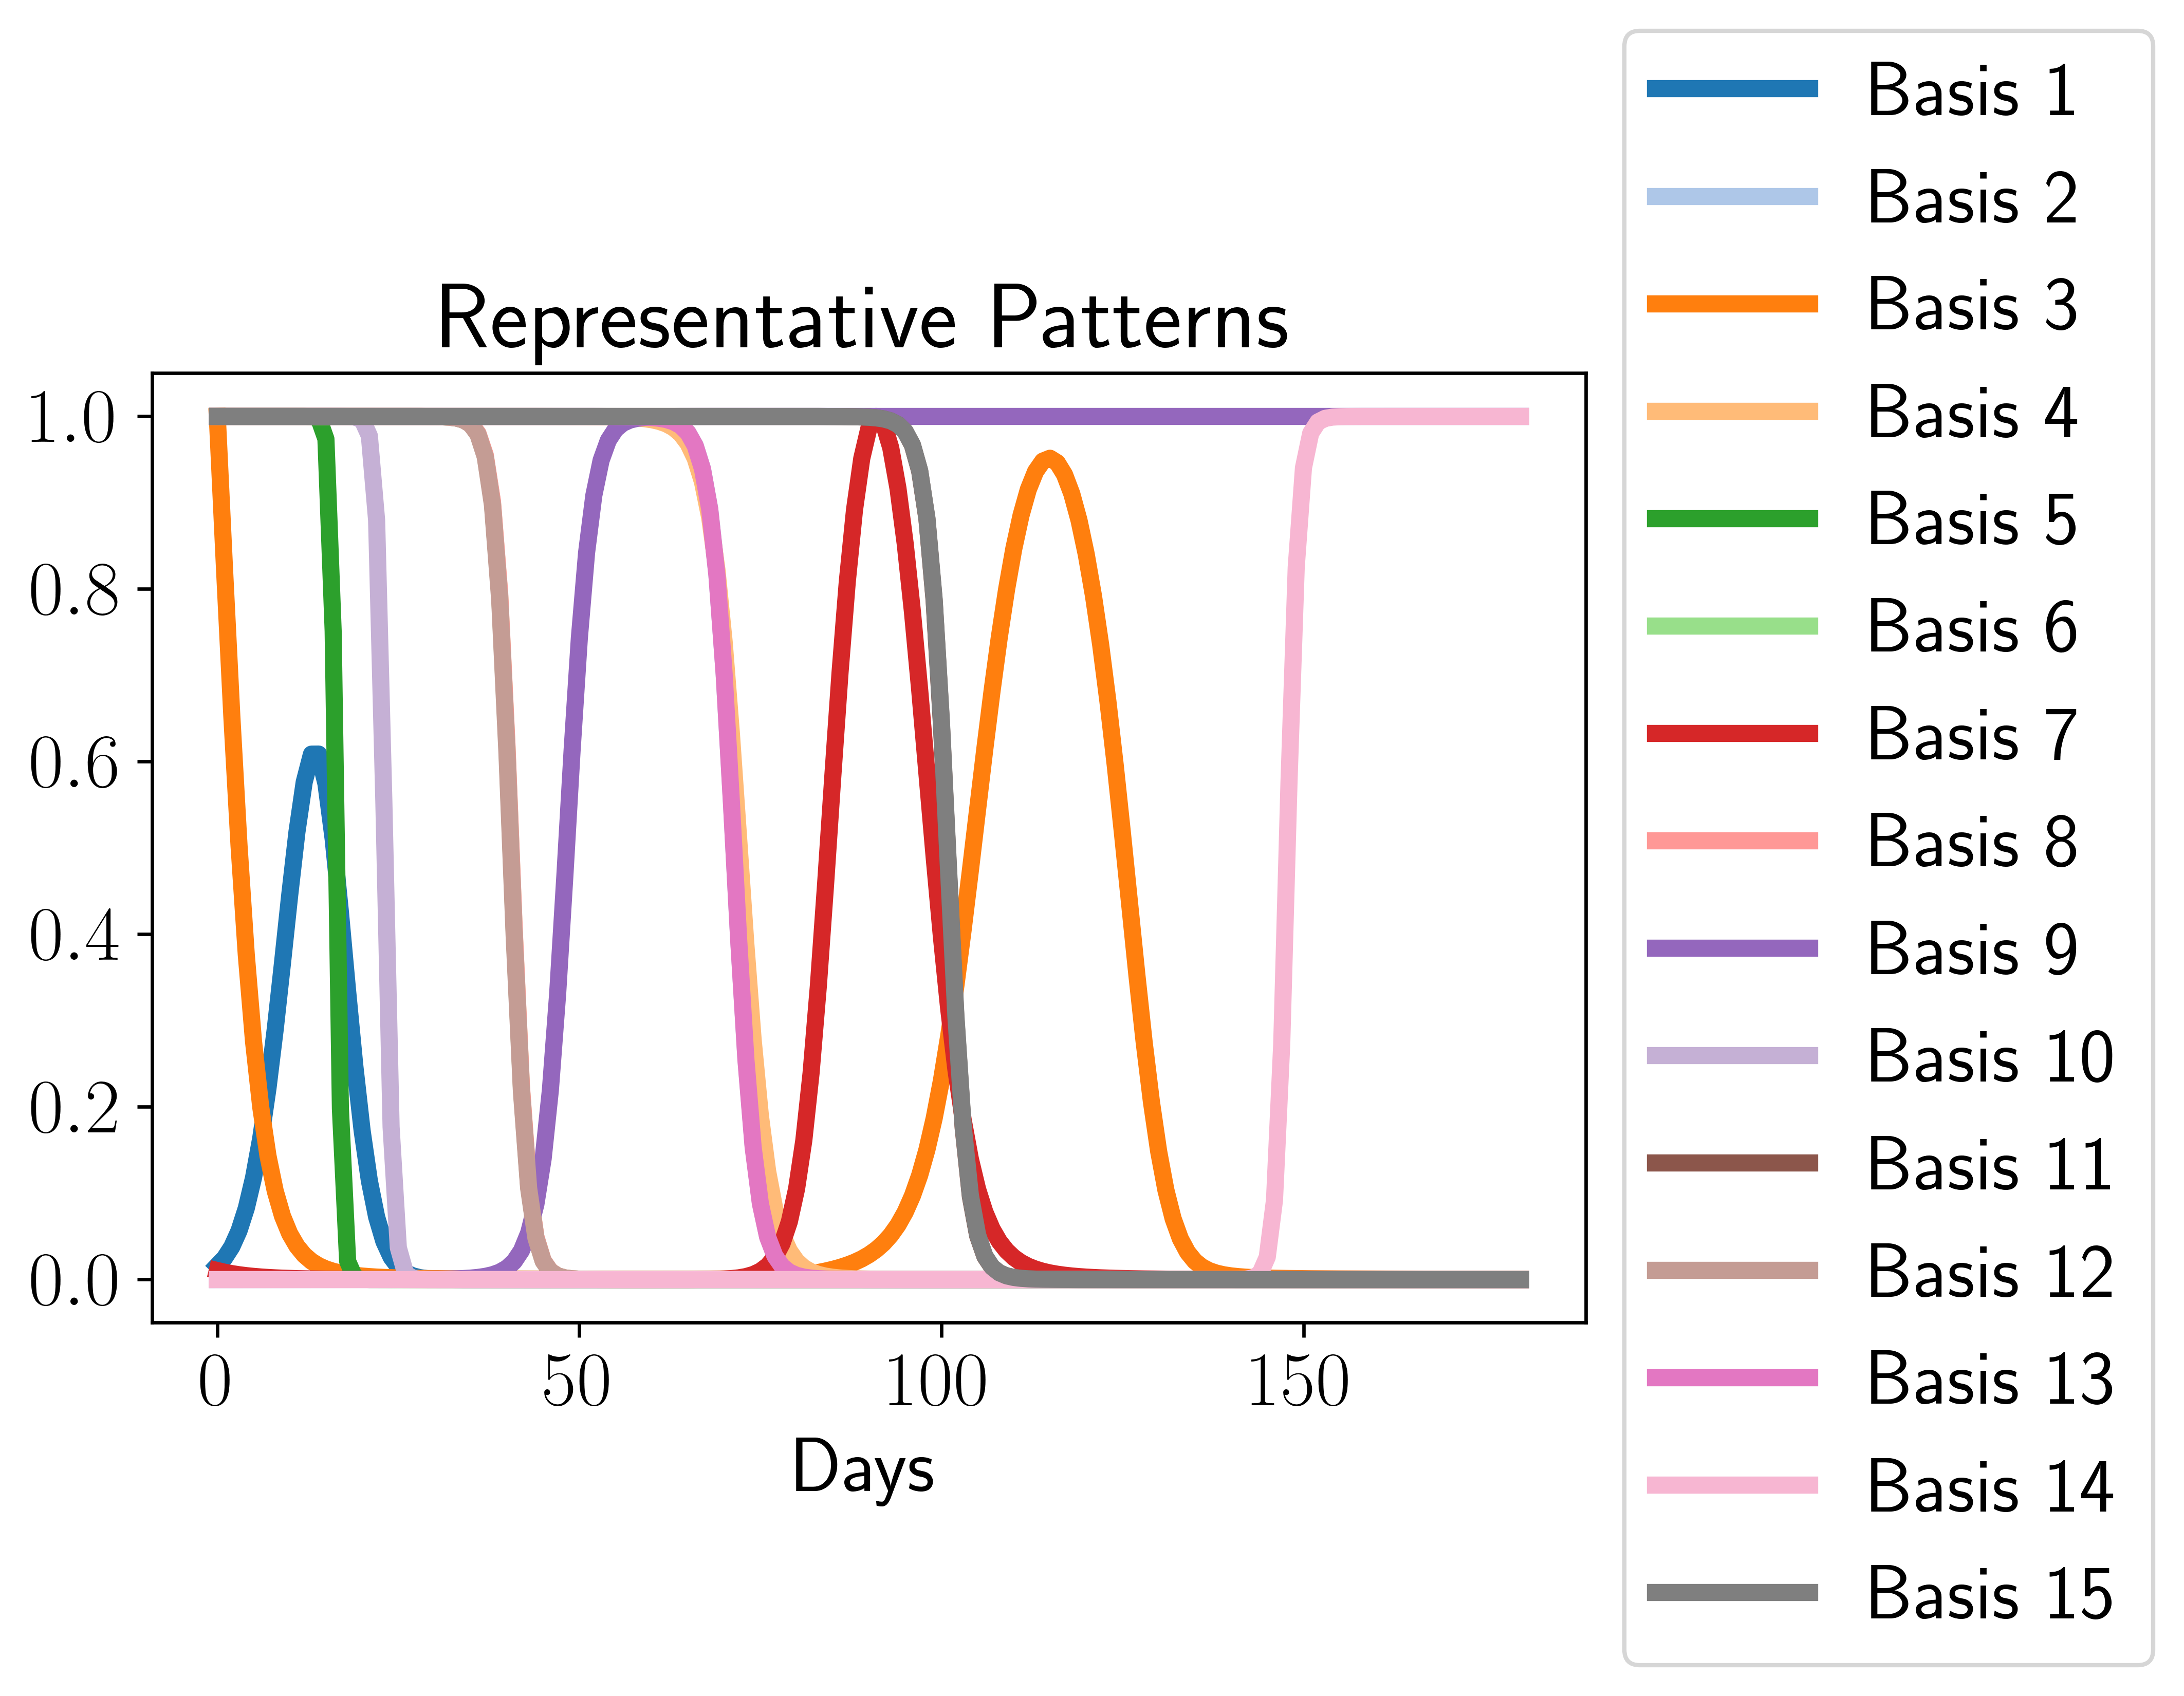

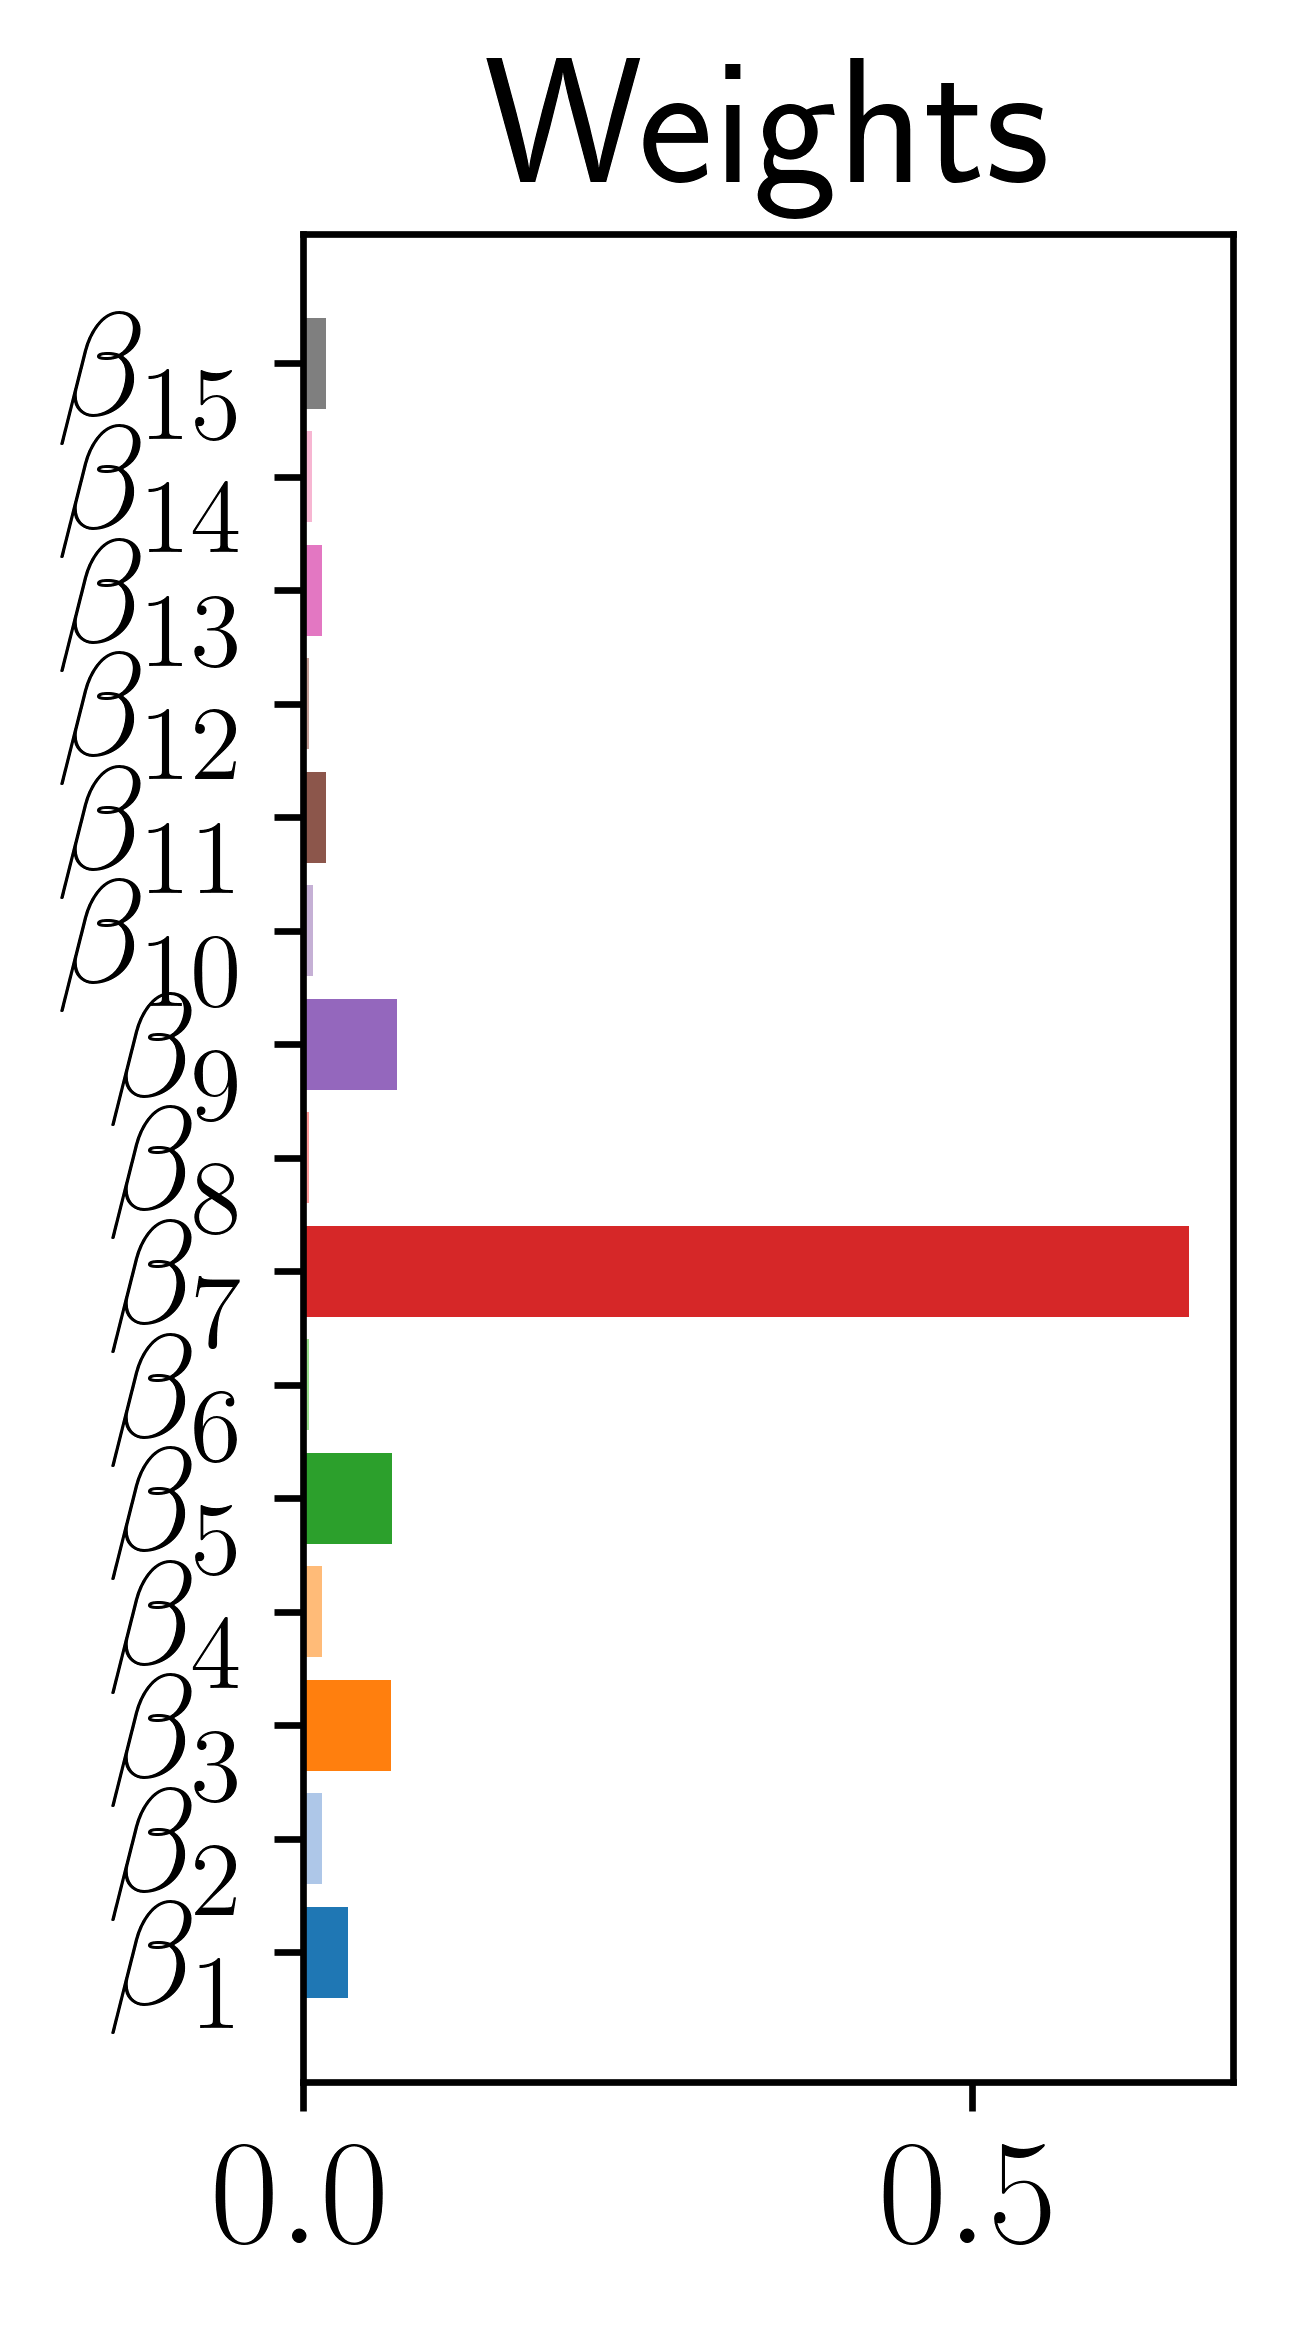

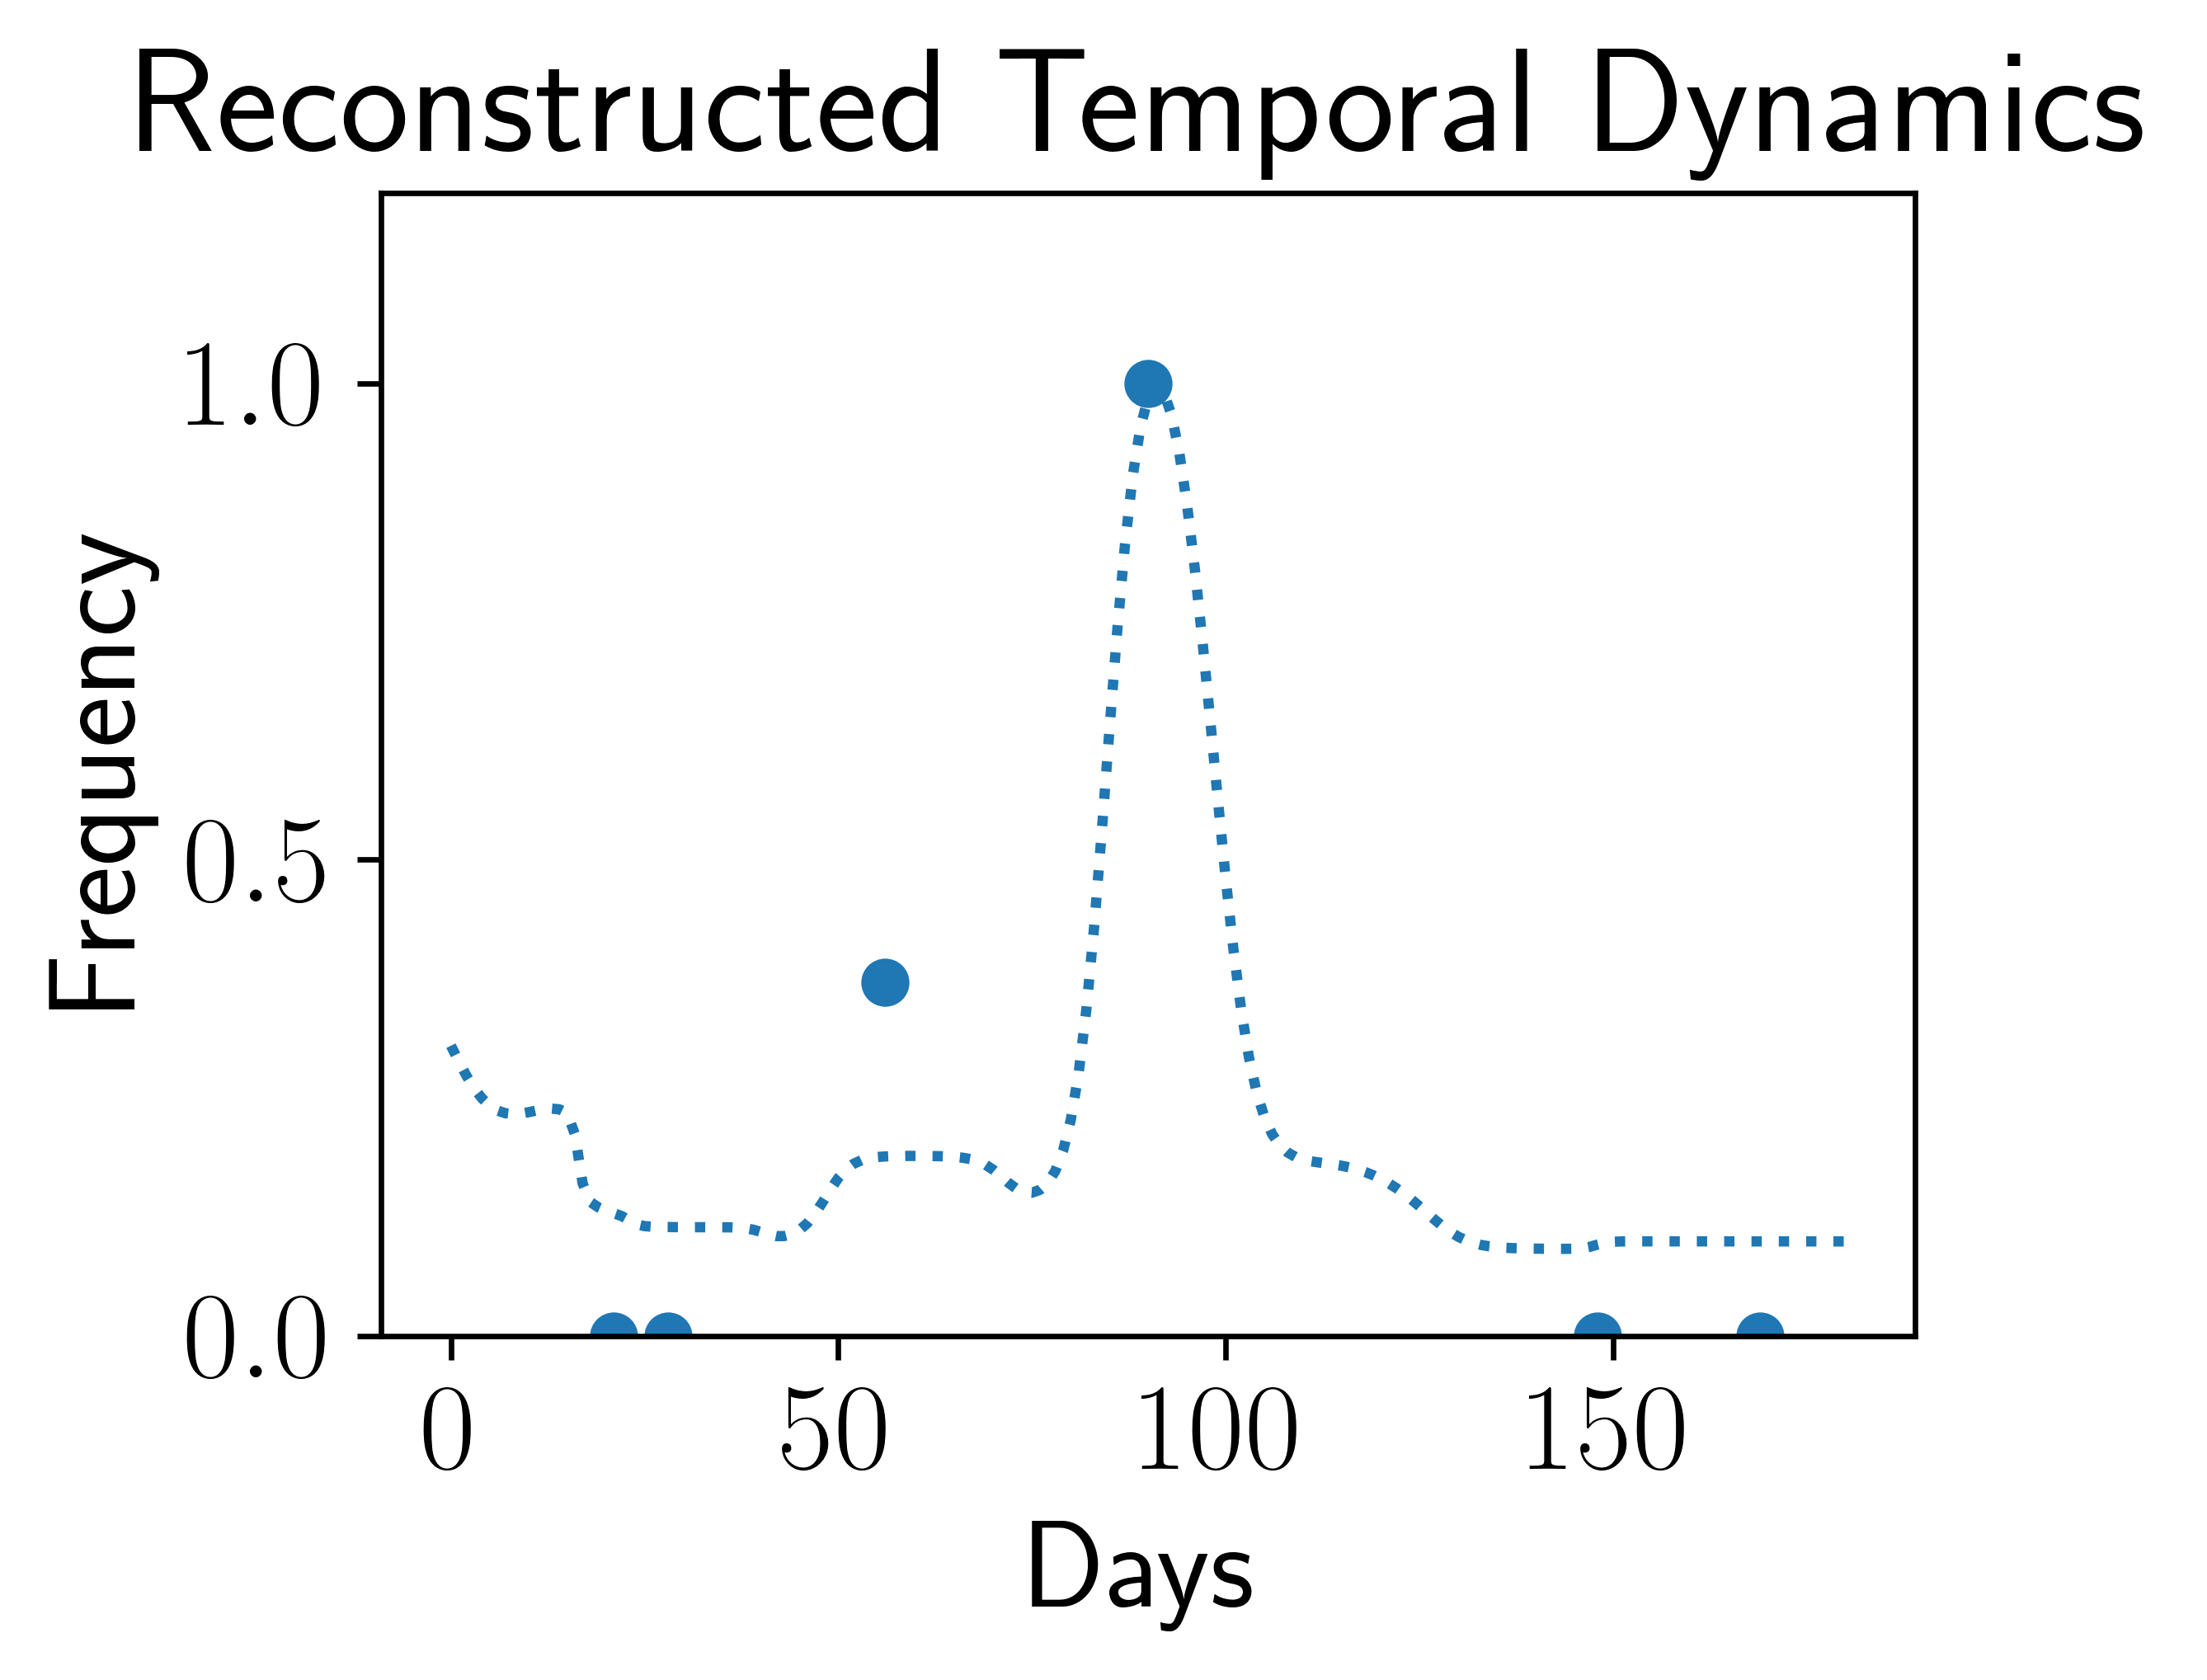

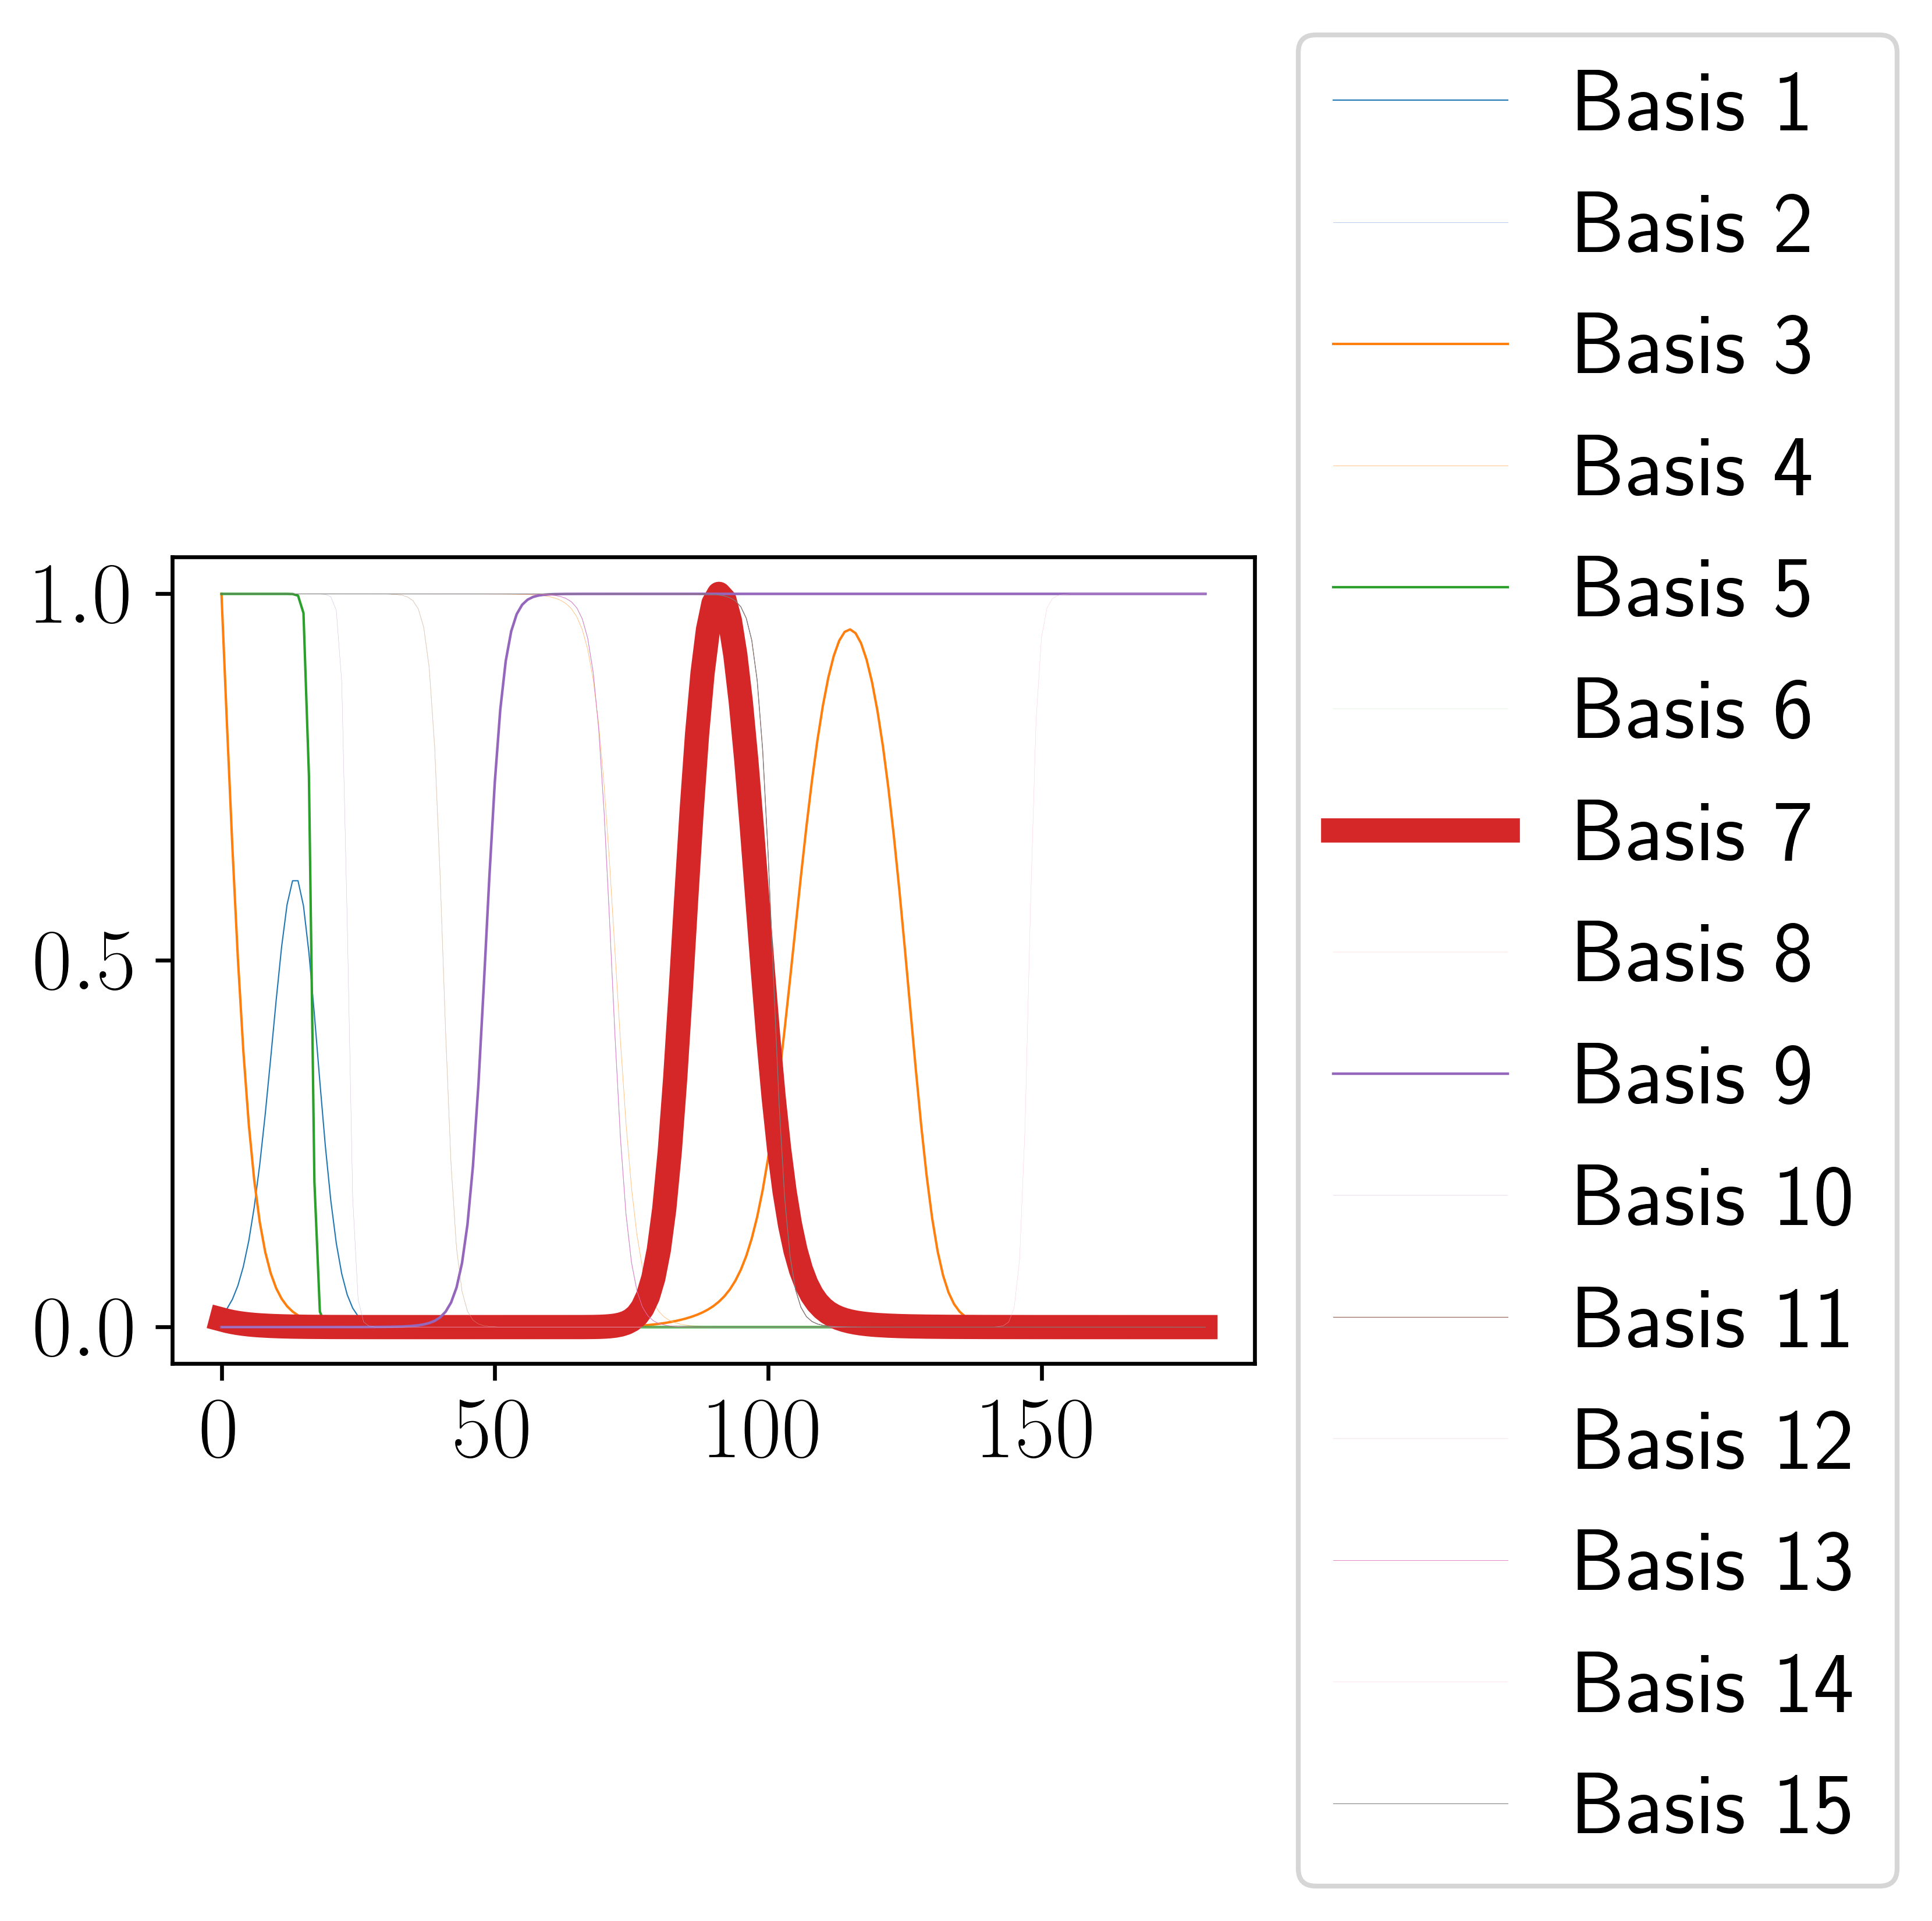

In [17]:


#Uncomment below to get the quantiles
# reconstruction_q05 = samples_a['_RETURN']['quantile05']
# reconstruction_q95 = samples_a['_RETURN']['quantile95']
reconstruction_std = samples_a['_RETURN']['std']

original = samples_a['obs']['mean']


plt.rcParams.update({'font.size': 18, "text.usetex":True })

m = 1
palette = sns.color_palette(n_colors = 1)[0]
idx = 0

#Scatter plot of the first clone pattern
fig, ax = plt.subplots(1,1, figsize = (4,3), dpi = 600)
idx = np.random.randint(0,len(clone_patterns_padded_allo_train))
ax.scatter(np.arange(0,181), clone_patterns_padded_allo_train[idx,:].detach().numpy(), color = palette)
ax.set_xlabel("Days")
ax.set_ylabel("Frequency")
ax.set_ylim([0,1.2])
ax.set_title("Time Series TCR Data")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels = ["example clone"])
plt.show()


sample_beta = samples_a["beta"]["mean"].squeeze()[idx,:]

#Plot the basis functions
fig, ax = plt.subplots(1,1, figsize = (6,4), dpi = 600)
for i in range(basis_a.shape[-1]):
    ax.plot(basis_a[:,i], linewidth = 4, color = sns.color_palette("tab20",n_colors=n_basis)[i])
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels = ["Basis {}".format(x) for x in range(1,n_basis+1)])
ax.set_title("Representative Patterns")
ax.set_xlabel("Days")
plt.show()

#Plot the basis weights
fig, ax = plt.subplots(1,1, figsize = (2,4), dpi = 600)
ax.barh(y = np.arange(1,n_basis + 1), width = sample_beta, color = sns.color_palette("tab20",n_colors=n_basis))
ax.set_yticks(np.arange(1,n_basis+1))
ax.set_yticklabels(["$\\beta_{"+str(x)+"}$" for x in range(1,n_basis+1)])
ax.set_title("Weights")
plt.show()


#Plot the fitted clone pattern
fig, ax = plt.subplots(1,1, figsize = (4,3), dpi = 600)
ax.scatter(np.arange(0,181), clone_patterns_padded_allo_train[idx,:].detach().numpy(), color = palette)
ax.plot(np.arange(0,181), reconstruction.numpy()[idx,:], ls = ':', color = palette)
ax.fill_between(np.arange(0,181), y1 = reconstruction.numpy()[idx,:] - reconstruction_std.numpy()[idx,:], y2 = reconstruction.numpy()[idx,:] + reconstruction_std.numpy()[idx,:], alpha = 0.2)
ax.set_xlabel("Days")
ax.set_ylabel("Frequency")
ax.set_title("Reconstructed Temporal Dynamics")
ax.set_ylim([0,1.2])
plt.show()


#Plot weighted Basis Functions. Line width is proportional to the weight of the basis function.
fig, ax = plt.subplots(1,1, figsize = (4,3), dpi = 600)
line_width = samples_a['beta']['mean'].squeeze()[idx,:]
line_width = line_width/line_width.max() * 5
for i in range(basis_a.shape[-1]):
    ax.plot(basis_a[:,i], linewidth = line_width[i], color = sns.color_palette("tab20",n_colors=n_basis)[i])
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels = ["Basis {}".format(x) for x in range(1,n_basis+1)])
plt.show()

0.7798065265733973


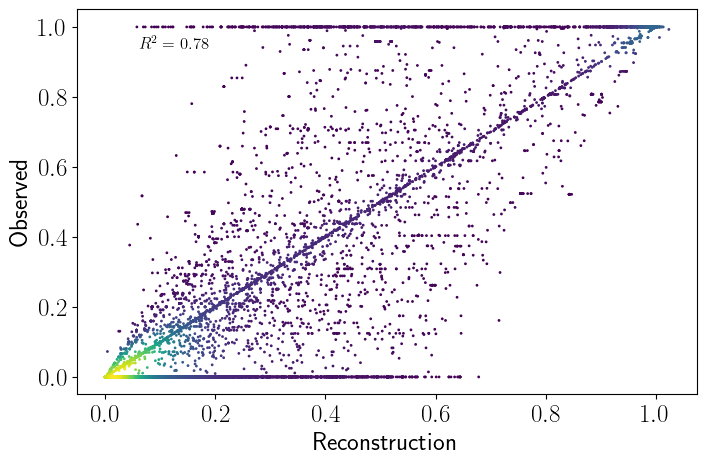

0.8212539738473092


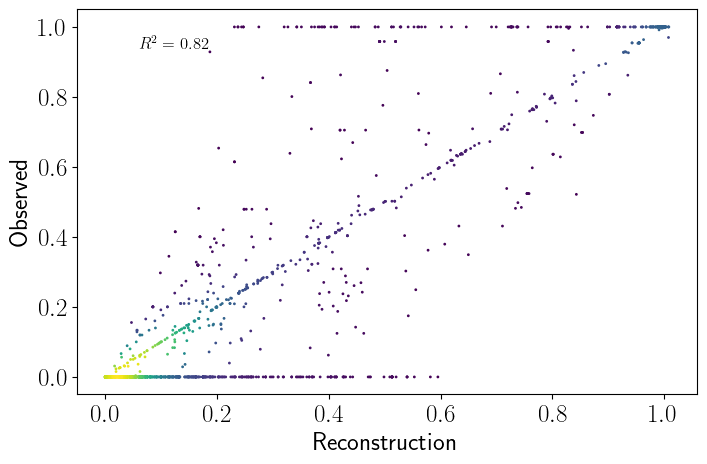

In [18]:

#To evaluate the model fit we want to compare the reconstruction vs the observed values for the training and validation data.
#Get reconstruction values and plot against observed and get R2 score
#Training Reconstruction Error
cmap = matplotlib.colormaps["viridis"]
reconstruction_val = samples_val["beta_val"]["mean"].squeeze() @ basis_a.T * model_val.gene_scales.detach().numpy()
reconstruction = samples_a['_RETURN']['mean']
original = samples_a['obs']['mean']

train_R2 = r2_score(clone_patterns_padded_allo_train.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())].flatten(),reconstruction.numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())].flatten())
print(train_R2)

d = np.vstack([reconstruction.numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())], clone_patterns_padded_allo_train.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())]])
kernel = gaussian_kde(d) #Fit Gaussian KDE to color the density of points
values = kernel(d)

fig, ax = plt.subplots(1,1, figsize = (8,5))

m = 5
ax.scatter(reconstruction.numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())], clone_patterns_padded_allo_train.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())], s = 1,
            c = values, cmap = cmap)
ax.text(0.1, 0.9, f'$R^2 = {train_R2:.2f}$', transform=plt.gca().transAxes, fontsize=12)
ax.set_ylabel("Observed")
ax.set_xlabel("Reconstruction")
plt.show()


#Validation Reconstruction Error
fig, ax = plt.subplots(1,1, figsize = (8,5))
val_R2 = r2_score(clone_patterns_padded_allo_val.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())].flatten(),reconstruction_val.numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())].flatten())
print(val_R2)

d = np.vstack([reconstruction_val.numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())], clone_patterns_padded_allo_val.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())]])
kernel = gaussian_kde(d) #Fit Gaussian KDE to color the density of points
values = kernel(d)

m = 5
plt.scatter(reconstruction_val.numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())], clone_patterns_padded_allo_val.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())], s = 1,
            c = values, cmap = cmap)
ax.text(0.1, 0.9, f'$R^2 = {val_R2:.2f}$', transform=plt.gca().transAxes, fontsize=12)
ax.set_ylabel("Observed")
ax.set_xlabel("Reconstruction")
plt.show()

Lets see how the model performs on some based on covariates

In [19]:
def plot_model_fit(basis, samples, samples_val, clone_scales, X_train, X_val, cov_train_idx = None, cov_val_idx = None):
    #To evaluate the model fit we want to compare the reconstruction vs the observed values for the training and validation data.
    #Get reconstruction values and plot against observed and get R2 score
    #Training Reconstruction Error
    
    if cov_train_idx is not None:
        X_train = X_train[cov_train_idx]
        reconstruction = samples['_RETURN']['mean'][cov_train_idx]
        original = samples['obs']['mean'][cov_train_idx]
                
    if cov_val_idx is not None:
        X_val = X_val[cov_val_idx]
        reconstruction_val = samples_val["beta_val"]["mean"].squeeze() @ basis.T * clone_scales
        reconstruction_val = reconstruction_val[cov_val_idx].detach()
        clone_scales = clone_scales[cov_val_idx]
        
    print(X_val.shape)
    print(reconstruction_val.shape)
        
    cmap = matplotlib.colormaps["viridis"]
    

    train_R2 = r2_score(X_train.detach().numpy()[~torch.isnan(X_train.detach())].flatten(),reconstruction.numpy()[~torch.isnan(X_train.detach())].flatten())
    print(train_R2)

    d = np.vstack([reconstruction.numpy()[~torch.isnan(X_train.detach())], X_train.detach().numpy()[~torch.isnan(X_train.detach())]])
    kernel = gaussian_kde(d) #Fit Gaussian KDE to color the density of points
    values = kernel(d)

    fig, ax = plt.subplots(1,1, figsize = (8,5))

    m = 5
    ax.scatter(reconstruction.numpy()[~torch.isnan(X_train.detach())], X_train.detach().numpy()[~torch.isnan(X_train.detach())], s = 1,
                c = values, cmap = cmap)
    ax.text(0.1, 0.9, f'$R^2 = {train_R2:.2f}$', transform=plt.gca().transAxes, fontsize=12)
    ax.set_ylabel("Observed")
    ax.set_xlabel("Reconstruction")
    plt.show()


    #Validation Reconstruction Error
    fig, ax = plt.subplots(1,1, figsize = (8,5))
    val_R2 = r2_score(X_val.detach().numpy()[~torch.isnan(X_val.detach())].flatten(),reconstruction_val.detach().numpy()[~torch.isnan(X_val.detach())].flatten())
    print(val_R2)

    d = np.vstack([reconstruction_val.detach().numpy()[~torch.isnan(X_val.detach())], X_val.detach().numpy()[~torch.isnan(X_val.detach())]])
    kernel = gaussian_kde(d) #Fit Gaussian KDE to color the density of points
    values = kernel(d)

    m = 5
    plt.scatter(reconstruction_val.numpy()[~torch.isnan(X_val.detach())], X_val.detach().numpy()[~torch.isnan(X_val.detach())], s = 1,
                c = values, cmap = cmap)
    ax.text(0.1, 0.9, f'$R^2 = {val_R2:.2f}$', transform=plt.gca().transAxes, fontsize=12)
    ax.set_ylabel("Observed")
    ax.set_xlabel("Reconstruction")
    plt.show()

In [20]:
# matplotlib.rcParams['text.usetex'] = False

reconstruction = samples_a['_RETURN']['mean']
reconstruction_std = samples_a["_RETURN"]["std"]

cmap = matplotlib.colormaps["viridis"]
reconstruction_val = samples_val["beta_val"]["mean"].squeeze() @ basis_a.T * model_val.gene_scales.detach().numpy()
reconstruction = samples_a['_RETURN']['mean']
original = samples_a['obs']['mean']

#Uncomment detach.numpy() if newly fitted model
clone_scales_a = clone_scales_a#.detach().numpy()
clone_scales_a = np.expand_dims(clone_scales_a, axis = 0)


beta_a = samples_a['beta']['mean'].squeeze() #Get weights
beta_a = beta_a[:len(train_a_idx)] #filter to only the training set
beta_and_scale_a = np.concatenate([beta_a], axis = 1)
beta_and_scale_df_a = pd.DataFrame(beta_and_scale_a)
col_names = np.concatenate([np.linspace(1, n_basis, n_basis, dtype = int).astype(str), ["clone_scales"]])

beta_a_val = samples_val['beta_val']['mean'].squeeze() #Get val weights
beta_a_val = beta_a_val[:len(val_a_idx)] #filter to only the validation set
beta_and_scale_a_val = np.concatenate([beta_a_val], axis = 1) 
beta_and_scale_df_a_val = pd.DataFrame(beta_and_scale_a_val)
col_names = np.concatenate([np.linspace(1, n_basis, n_basis, dtype = int).astype(str), ["clone_scales"]])


#Perform clustering on the basis weights and clone scales. Can be displayed with UMAP or Clustermaps. Not cricitical for analysis.
adjacency = kneighbors_graph(np.concatenate([beta_and_scale_df_a.values,beta_and_scale_df_a_val.values]), 
                             n_neighbors = 30, 
                             mode = "distance" , 
                             metric = "euclidean")


#Cluster with Louvain
louvain = Louvain(.05)
labels_allo = louvain.fit_predict(adjacency)
labels_allo_train = labels_allo[:beta_and_scale_a.shape[0]]
labels_allo_val = labels_allo[beta_and_scale_a.shape[0]:]

data_filt_a_train = data_filt_a.iloc[train_a_idx,:].reset_index(drop = True)
data_filt_a_train["Data"] = "Training"
data_filt_a_val = data_filt_a.iloc[val_a_idx,:].reset_index(drop = True)
data_filt_a_val["Data"] = "Validation"

data_filt_a_cat = pd.concat([data_filt_a_train, data_filt_a_val])
data_filt_a_cat["Cluster"] = labels_allo

data_filt_a_cat = data_filt_a_cat.reset_index(drop = True)

data_filt_a_cat_all = pd.concat([data_filt_a_cat,pd.DataFrame(np.concatenate([beta_a,beta_a_val]))], axis = 1 , join = "inner").drop(["index"], axis = 1)
data_filt_a_cat_all.to_csv("Clustered_Allo.csv")

#Increment column names by 1 to match basis numbering
beta_and_scale_df_a.columns += 1 
beta_and_scale_df_a_val.columns += 1


clone_scales_all = pd.DataFrame({"clone_scales":np.concatenate([clone_scales_a.squeeze(), clone_scales_val.detach().numpy().squeeze()], axis = 0)})
data_filt_a_cat_all_cs = pd.concat([data_filt_a_cat_all, clone_scales_all], axis = 1)

#Uncomment below to save the clustered data
# data_filt_a_cat_all_cs.to_csv("Clustered_Allo_cs.csv")


Notice that for the previously fitted basis, there are some repeated basis. In our analysis we would like to combine these basis and their weights. We first look at their covariance or correlation to see which basis are identical. Either correlation or covaraince can be used and should give same results.

In [21]:
import scipy.cluster.hierarchy as sc

#Now check how the correlation compares, should get same results as above
# Calculate the correlation matrix
cov_matrix = beta_and_scale_df_a.corr()

# Create a custom clustermap with masked upper triangle
sns.set(style='white')
cg = sns.clustermap(cov_matrix, cmap='vlag', figsize=(10, 10), metric = "euclidean", vmin = -1, vmax = 1) 
plt.close() #comment to visualize
# cg.savefig("../output_data/Basis_figures/Figure2ex/CorrMatrix.png", dpi = 600, bbox_inches='tight')
# cg.savefig("../output_data/Basis_figures/Figure2ex/CorrMatrix.pdf", dpi = 600, bbox_inches='tight')

# Extract the column linkage matrix
dendrogram = cg.dendrogram_row.linkage
reord_ind = np.arange(1, n_basis+1,1)


height_threshold = 1
clusters = sc.cut_tree(dendrogram, height=height_threshold).flatten()
basis_clust = []
for i in np.unique(clusters):
    basis_clust.append(reord_ind[clusters == i])
    print("Cluster {}: = {}".format(i, reord_ind[clusters == i]))

Cluster 0: = [1]
Cluster 1: = [ 2  4 13]
Cluster 2: = [3]
Cluster 3: = [5]
Cluster 4: = [ 6  8 12]
Cluster 5: = [7]
Cluster 6: = [9]
Cluster 7: = [10]
Cluster 8: = [11 15]
Cluster 9: = [14]


Notice that in the above that there a basis with nearly perfect correlation. These are the ones we would like to combine.

In [22]:
#Get Basis
basis_a_comb = basis_a.copy()
beta_and_scale_df_a_comb = beta_and_scale_df_a.copy()
del_basis = np.empty(0, dtype = int) #Store indices of basis to delete

#Combine basis functions that are similar and sum the beta values and normalize the basis function
for clust in basis_clust:
    if len(clust) > 1:
        del_basis = np.append(del_basis, clust[1:])
        basis_a_comb[:,clust[0]-1] = np.sum(basis_a_comb[:,clust-1], axis = 1)/len(clust)
        beta_and_scale_df_a_comb[clust[0]] = beta_and_scale_df_a_comb[clust].sum(axis = 1)

print(del_basis-1)
beta_and_scale_df_a_comb = beta_and_scale_df_a_comb.drop(del_basis,axis = 1)
basis_a_comb = np.delete(basis_a_comb, del_basis-1, 1)
        
beta_and_scale_df_a_comb.columns = range(1,len(beta_and_scale_df_a_comb.columns)+1,1)



[ 3 12  7 11 14]


In [23]:
#Redo above to see if there are any strong blocks on the diagonal.
# Calculate the correlation matrix
cov_matrix = beta_and_scale_df_a_comb.corr()
cov_matrix.columns += 1

# Create a custom clustermap with masked upper triangle
sns.set(style='white')
cg = sns.clustermap(cov_matrix, cmap='vlag', figsize=(10, 10), metric = "cosine") 
plt.close() #comment to visualize
# cg.savefig("../output_data/Basis_figures/Figure2ex/CorrMatrixComb.png", dpi = 600, bbox_inches='tight')
# cg.savefig("../output_data/Basis_figures/Figure2ex/CorrMatrixComb.pdf", dpi = 600, bbox_inches='tight')


# Extract the column linkage matrix
dendrogram = cg.dendrogram_row.linkage
reord_ind = np.arange(1, cov_matrix.shape[0]+1,1)


height_threshold = .1
clusters = sc.cut_tree(dendrogram, height=height_threshold).flatten()
basis_clust = []
for i in np.unique(clusters):
    basis_clust.append(reord_ind[clusters == i])
    print("Cluster {}: = {}".format(i, reord_ind[clusters == i]))

Cluster 0: = [1]
Cluster 1: = [2]
Cluster 2: = [3]
Cluster 3: = [4]
Cluster 4: = [5]
Cluster 5: = [6]
Cluster 6: = [7]
Cluster 7: = [8]
Cluster 8: = [9]
Cluster 9: = [10]


In [24]:
import scipy.cluster.hierarchy as sc

# Calculate the correlation matrix
cov_matrix = pd.DataFrame(basis_a_comb).corr()
cov_matrix.columns += 1

# Create a custom clustermap with masked upper triangle
sns.set(style='white')
cg = sns.clustermap(cov_matrix, cmap='vlag', figsize=(10, 10), metric = "euclidean", vmin = -1, vmax = 1)
plt.close() #comment to visualize

# Extract the column linkage matrix
dendrogram = cg.dendrogram_row.linkage
reord_ind = np.arange(1, cov_matrix.shape[0]+1,1)


height_threshold = 0.1
clusters = sc.cut_tree(dendrogram, height=height_threshold).flatten()
basis_clust = []
for i in np.unique(clusters):
    basis_clust.append(reord_ind[clusters == i])
    print("Cluster {}: = {}".format(i, reord_ind[clusters == i]))

Cluster 0: = [1]
Cluster 1: = [2]
Cluster 2: = [3]
Cluster 3: = [4]
Cluster 4: = [5]
Cluster 5: = [6]
Cluster 6: = [7]
Cluster 7: = [8]
Cluster 8: = [9]
Cluster 9: = [10]


We can still have correlated functions but their correlations are not as close to 1 as before.

## Displaying Results and Statistical Analysis

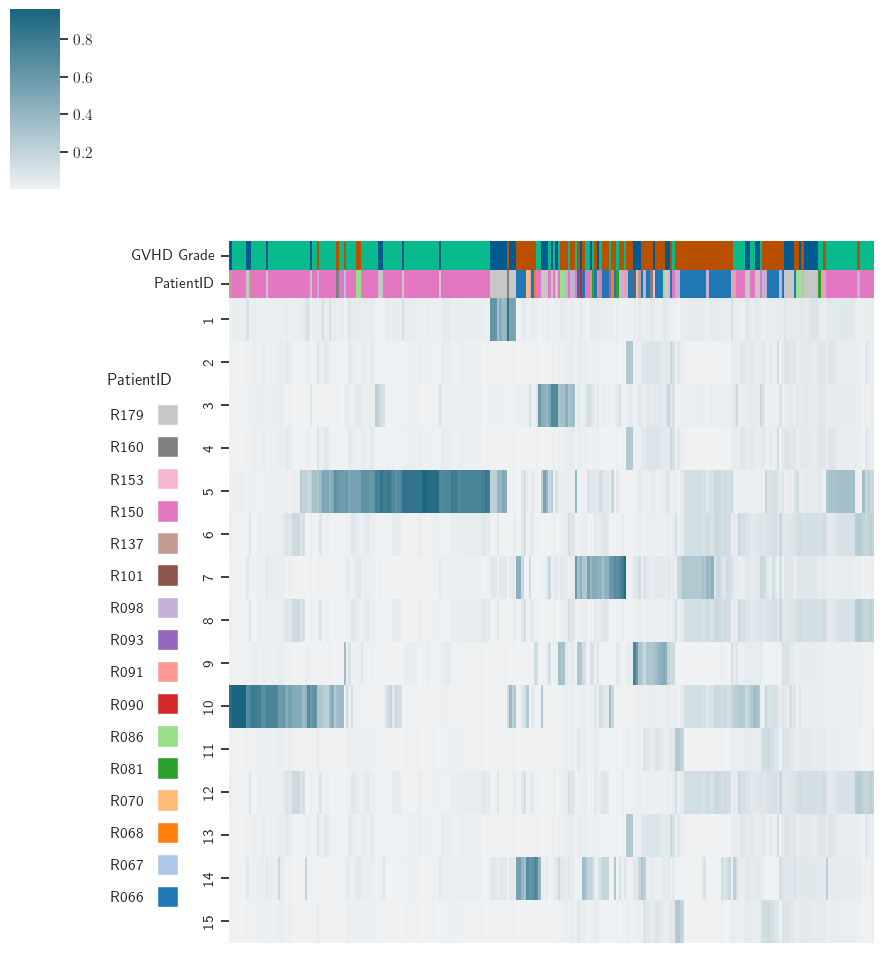

/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


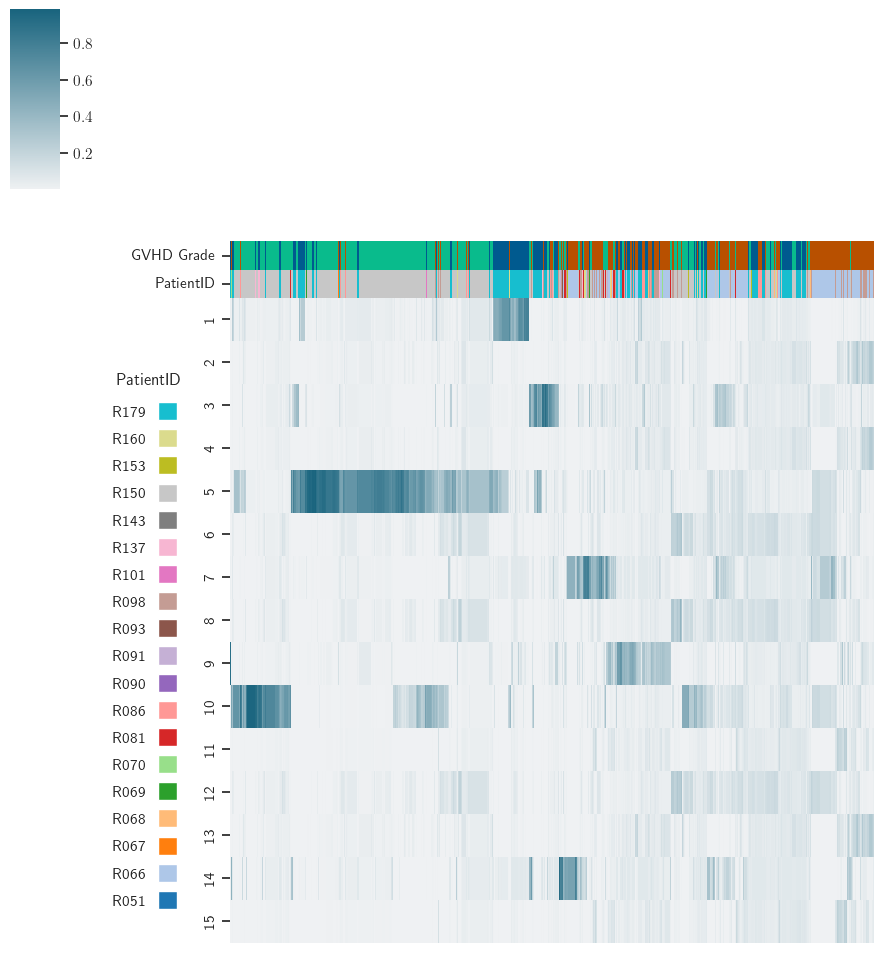

/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


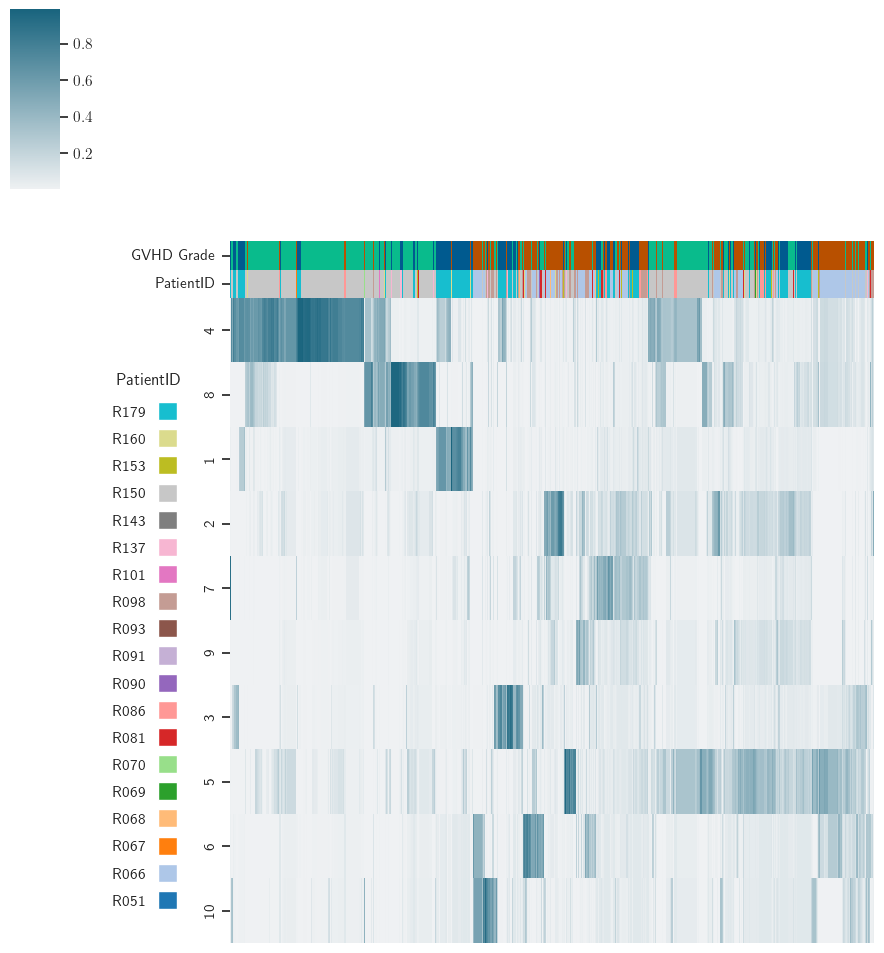

In [25]:
row_categories = ["GVHD Grade", "PatientID"]
data_filt_a_val["GVHD Grade"] = pd.Categorical(data_filt_a_val["GVHD_GRADE_1"].astype(str), ["No", "Mild", "Severe"], ordered = False)
data_filt_a_val["GVHD Grade"] = data_filt_a_val["GVHD_GRADE_1"]


data_filt_a_train["GVHD Grade"] = pd.Categorical(data_filt_a_train["GVHD_GRADE_1"].astype(str), ["No", "Mild", "Severe"], ordered = True)
data_filt_a_train["GVHD Grade"] = data_filt_a_train["GVHD_GRADE_1"]

legend_positions = np.array([[-10,6.0, .75,.75],
          [1.3,0.05, .75,.75],])

legend_colors = [
    sns.color_palette(["#005A8F", "#09BB8C" , "#B85000"]),
    sns.color_palette("tab20", len(np.unique(data_filt_a_train["PatientID"]))),
]

offset = [-1, -2.3,]

legend_sizes = [
    (1,1),
    (1,7),
]

#Clustermap of Validation Data
clustermap(beta_and_scale_df_a_val,data_filt_a_val, row_categories, offset, legend_positions, legend_colors, legend_sizes, "GVHD")

#Clustermap of Training Data
clustermap(beta_and_scale_df_a, data_filt_a_train.drop("index", axis = 1), row_categories, offset, legend_positions, legend_colors, legend_sizes, "GVHD")


#Reorder the columns of beta_and_scale_df_a_comb to match the order of the clusters
beta_and_scale_df_a_comb_reord = beta_and_scale_df_a_comb[[4,8,1,2,7,9,3,5,6,10]]

#Display reordered clustermap of combined data
ax = clustermap(beta_and_scale_df_a_comb_reord, data_filt_a_train.drop("index", axis = 1), row_categories, offset, legend_positions, legend_colors, legend_sizes, "GVHD")

#Uncomment below to save the clustermap
# ax.savefig("../output_data/Basis_figures/Figure2/BasisHeatmap.png", dpi = 600, bbox_inches='tight')
# ax.savefig("../output_data/Basis_figures/Figure2/BasisHeatmap.pdf", dpi = 600, bbox_inches='tight')



In [26]:
data_filt_a_val.columns

Index(['index', 'templates', 'tag', 'PatientID', 'cdr3_amino_acid',
       'v_resolved', 'j_resolved', 'ifexpanded', 'allo', 'cell_type',
       'GVHD_GRADE_1', 'GVHD_GRADE_2', 'GVHD_GRADE_3', 'Onset', 'Age_R',
       'DonorType', 'PTCy', 'Sex', 'HLA_mis', 'Conditioning', 'mapped',
       'Tissue_Location', 'Migration_all', 'leiden_0.5', 'clone_encoding',
       'Data', 'GVHD Grade'],
      dtype='object')

In [27]:
data_filt_a_train.Conditioning.unique()

array(['Clofarabine/Busulfan', 'Flu/TBI', 'Flu/Bu2/TBI',
       'Flu/Busulfan x4', 'Flu/Melphalan/Campath (Alemtuzumab)',
       'Flu/Busulfan x2/Thiotepa', 'Flu/Busulfan x2', 'Flu/Melphalan',
       'Flu/Busulfan 2x', 'TBI/Cy', 'Flu/Melphalan/TBI',
       'Flu/Bu2/Thiopeta'], dtype=object)

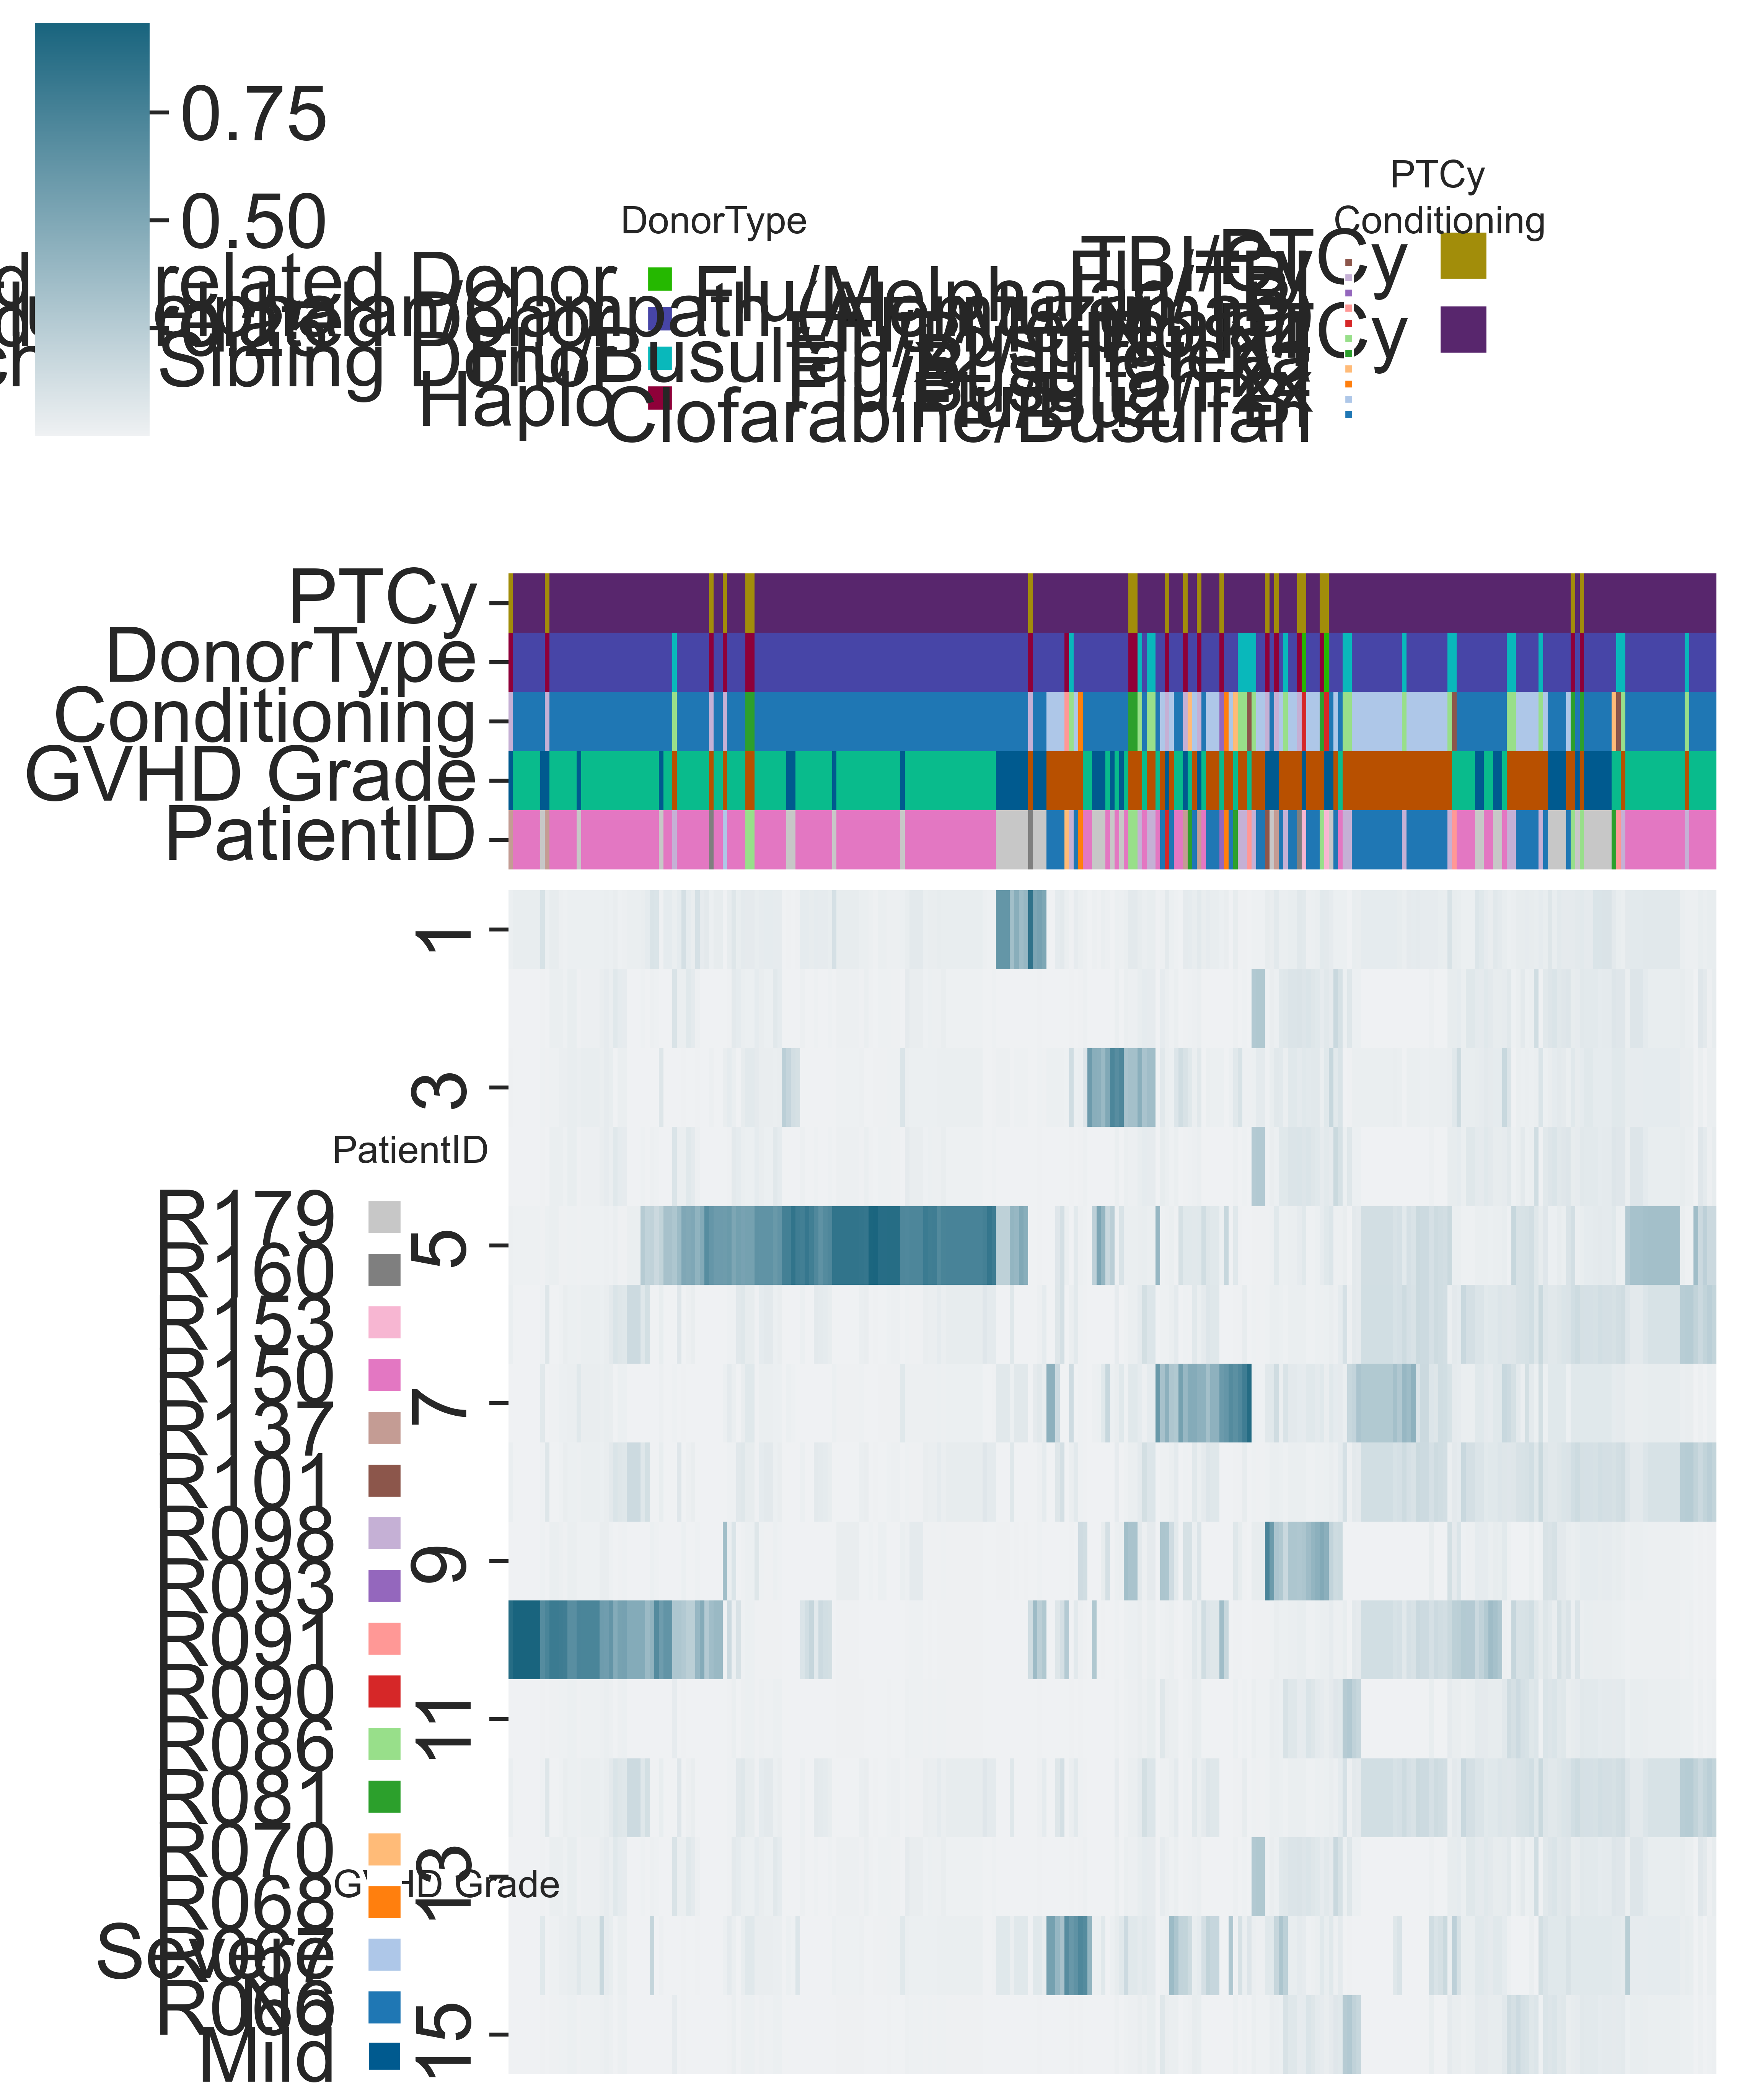

/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


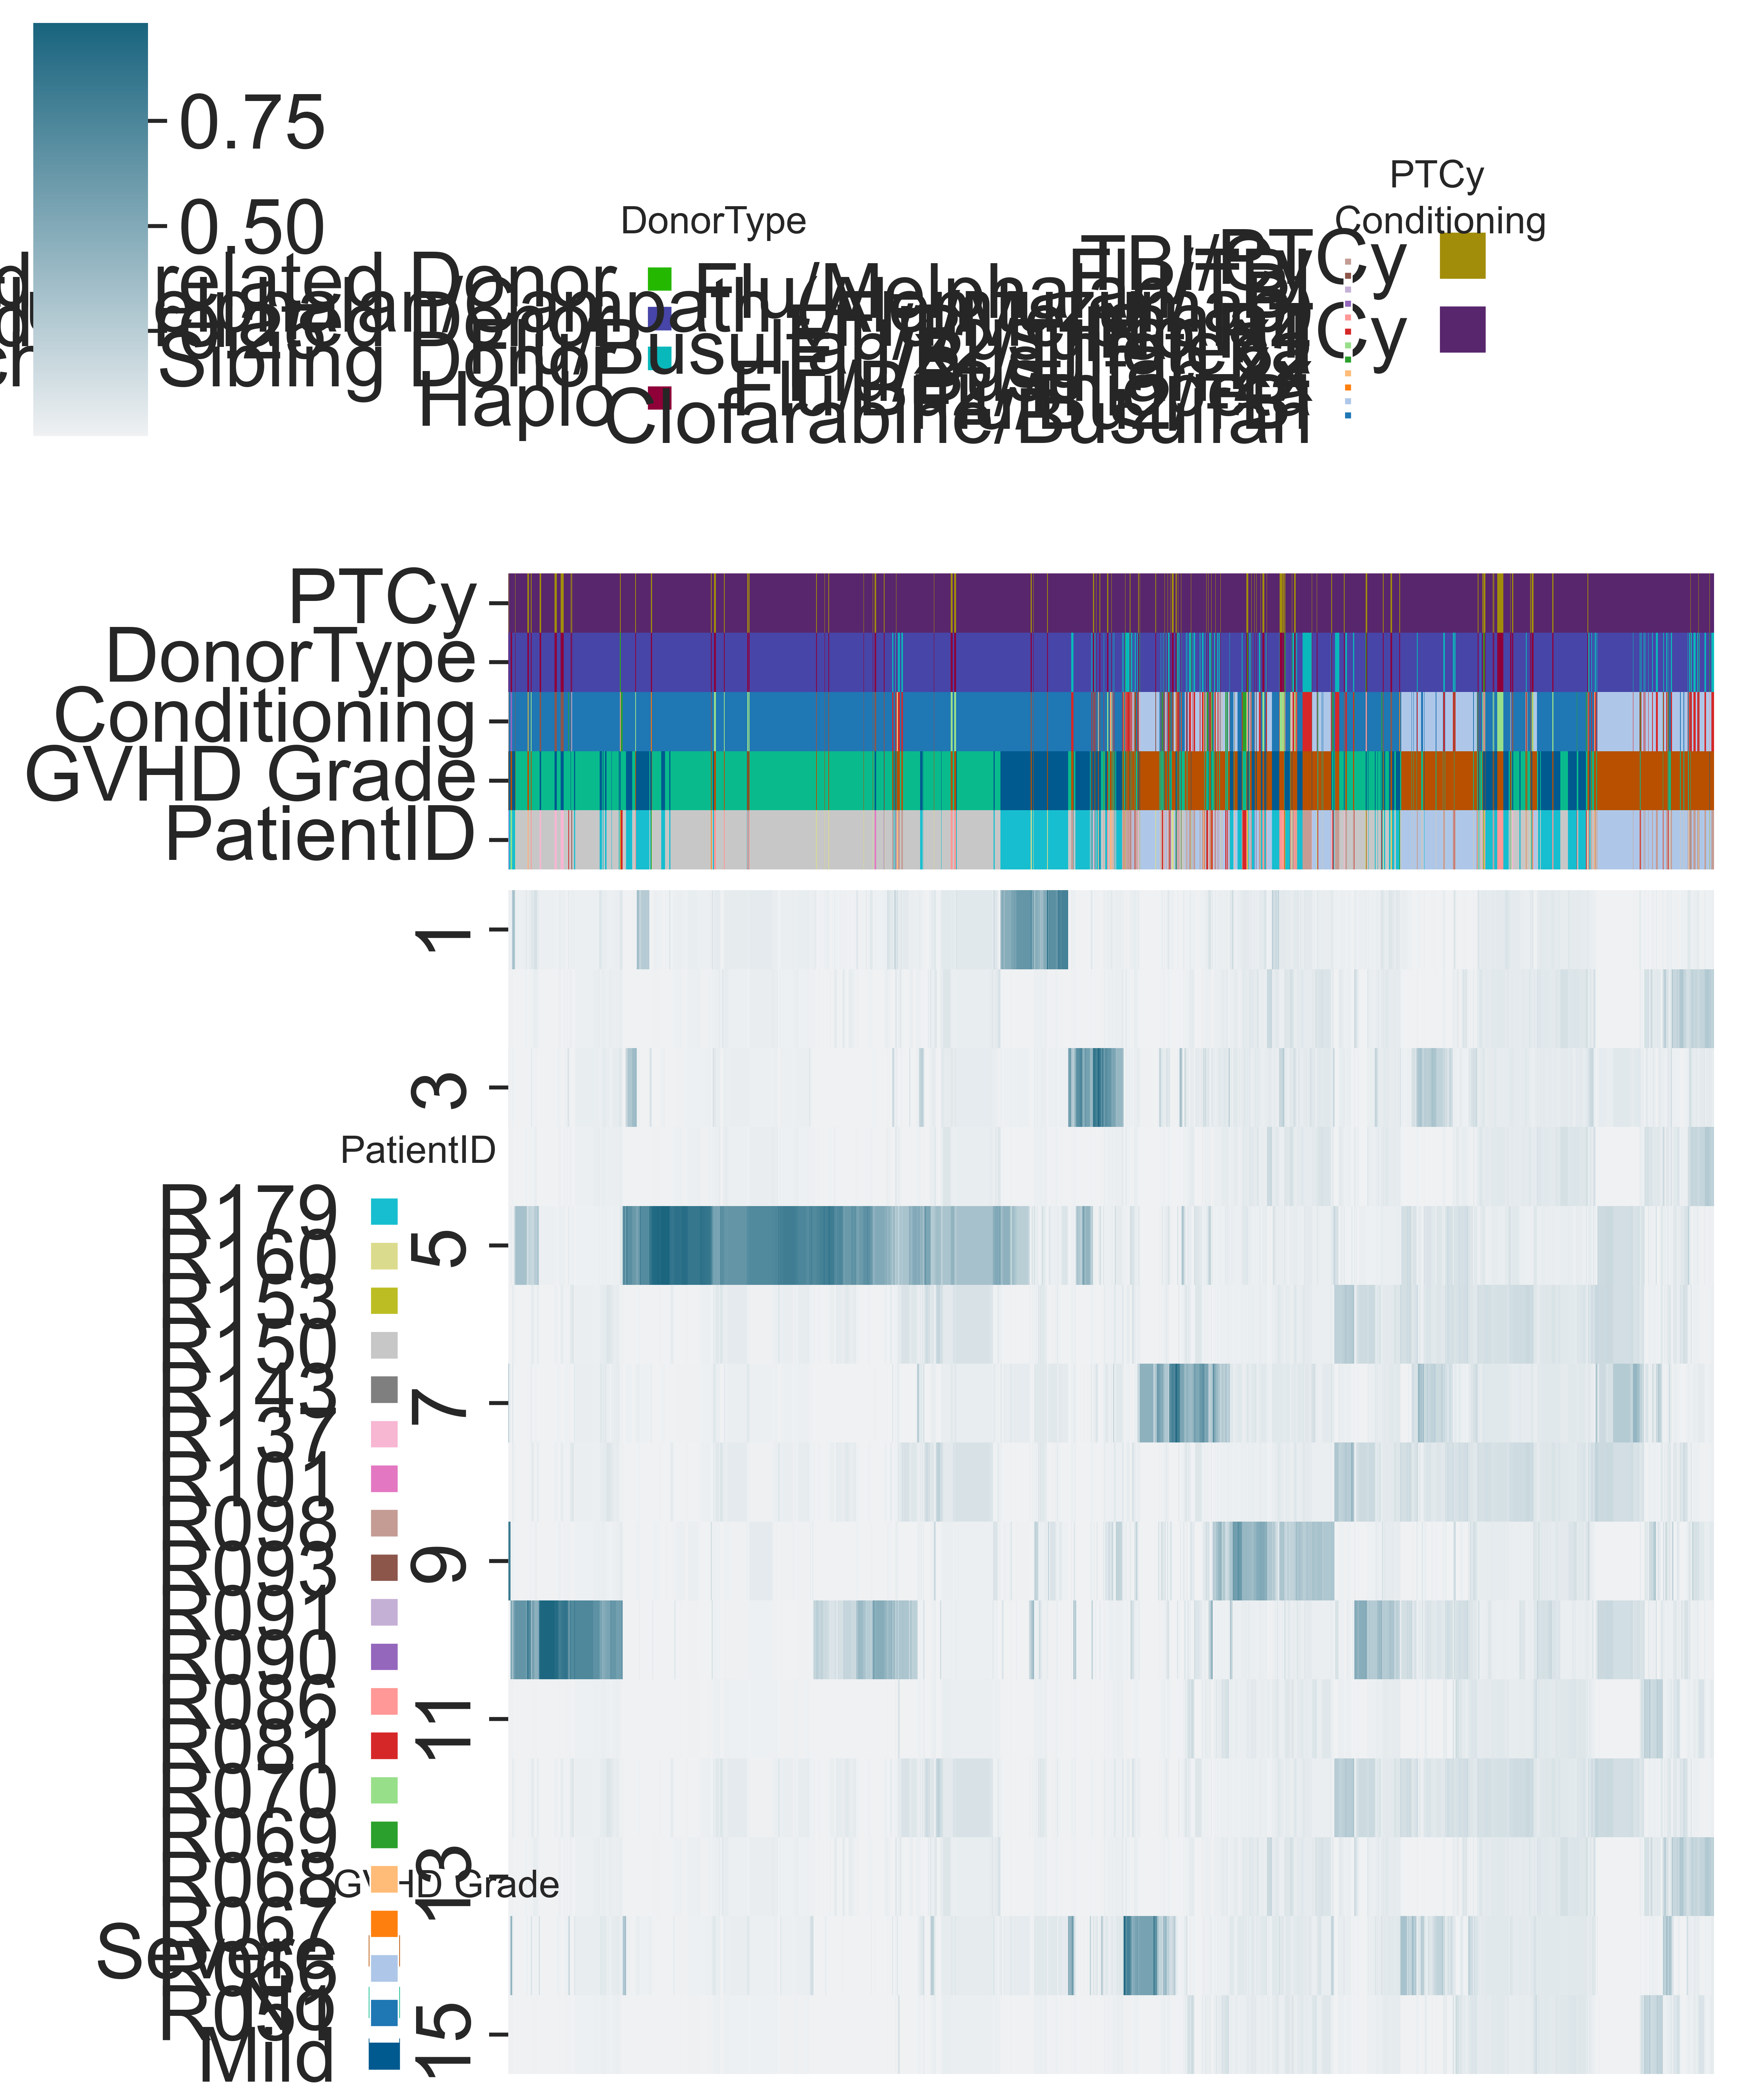

/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


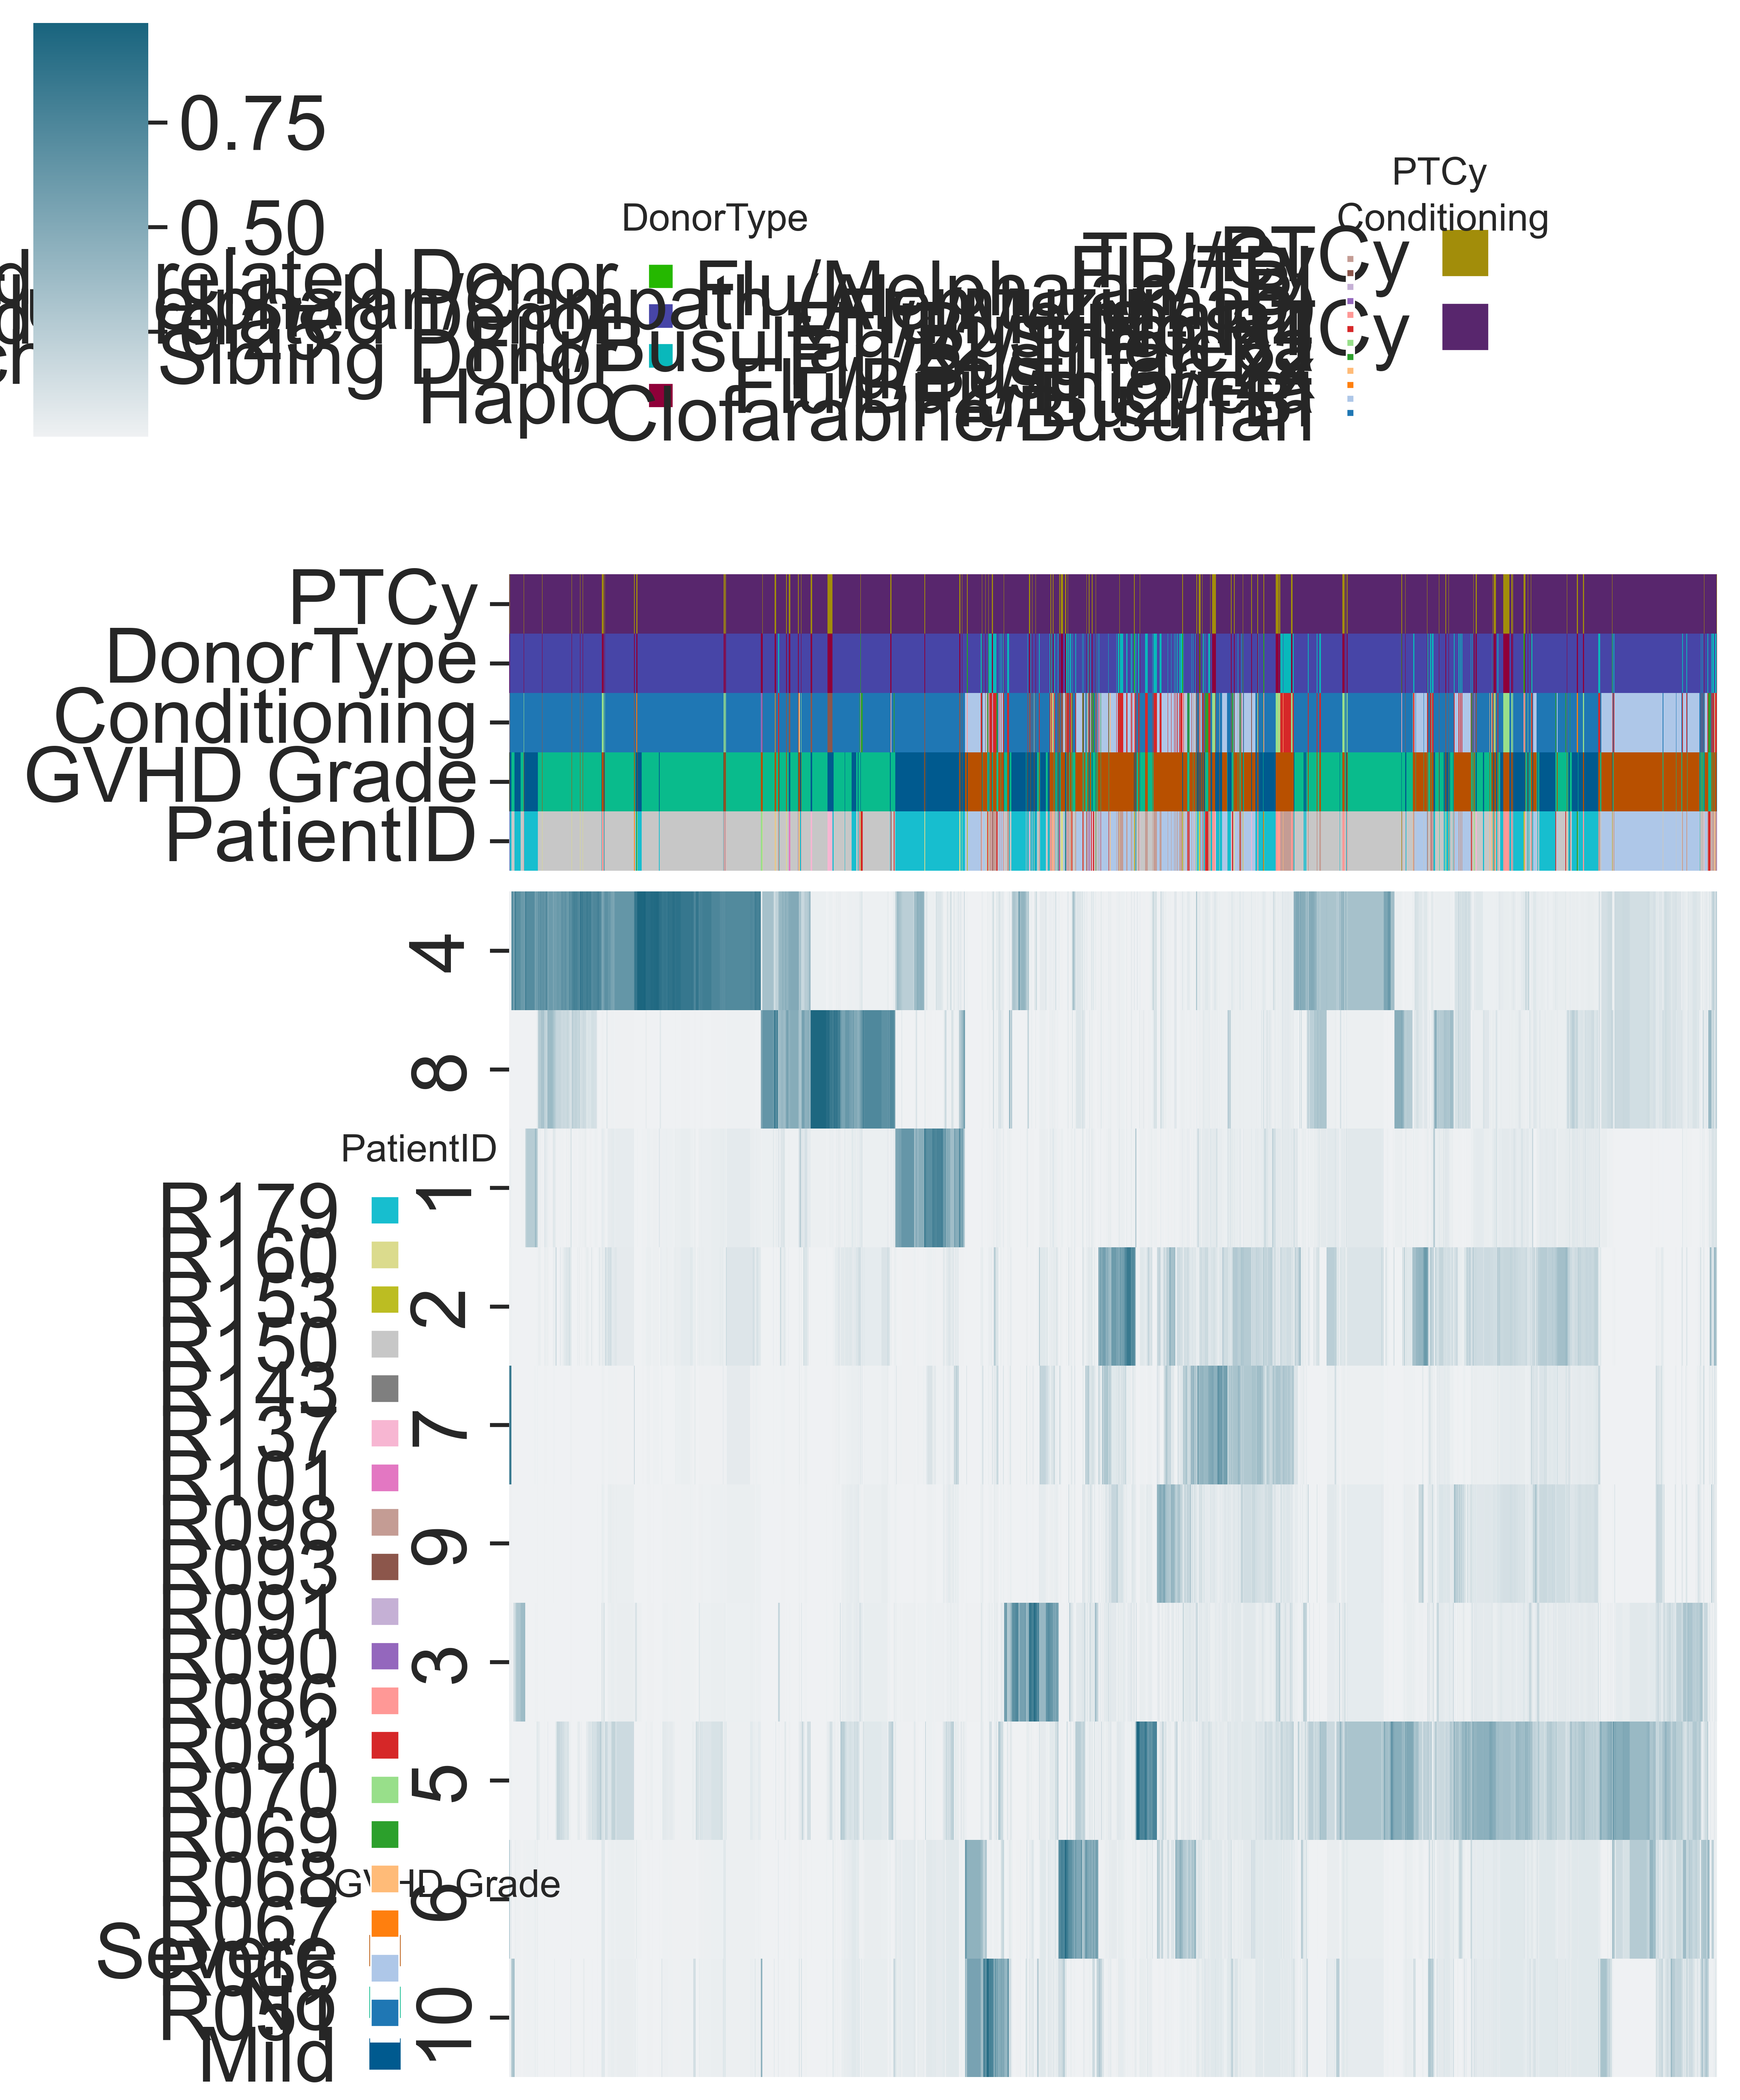

In [43]:
row_categories = ["PTCy", "DonorType", "Conditioning", "GVHD Grade", "PatientID"]
data_filt_a_val["PTCy"] = pd.Categorical(data_filt_a_val["PTCy"].astype(str), ["PTCy", "No PTCy"], ordered = False)
data_filt_a_train["PTCy"] = pd.Categorical(data_filt_a_train["PTCy"].astype(str), ["PTCy", "No PTCy"], ordered = True)


data_filt_a_val["DonorType"] = pd.Categorical(data_filt_a_val["DonorType"].astype(str), ["Matched Unrelated Donor", "Haplo", "Matched Sibling Donor", 'Mismatched Unrelated Donor'], ordered = False)
data_filt_a_train["DonorType"] = pd.Categorical(data_filt_a_train["DonorType"].astype(str), ["Matched Unrelated Donor", "Haplo", "Matched Sibling Donor", 'Mismatched Unrelated Donor'], ordered = False)


data_filt_a_val["GVHD Grade"] = pd.Categorical(data_filt_a_val["GVHD_GRADE_1"].astype(str), ["No", "Mild", "Severe"], ordered = False)
data_filt_a_val["GVHD Grade"] = data_filt_a_val["GVHD_GRADE_1"]


data_filt_a_train["GVHD Grade"] = pd.Categorical(data_filt_a_train["GVHD_GRADE_1"].astype(str), ["No", "Mild", "Severe"], ordered = True)
data_filt_a_train["GVHD Grade"] = data_filt_a_train["GVHD_GRADE_1"]

legend_positions = np.array([
    [6, 7.5, .75,.75],
    [2.5, 7.3, .75,.75],
    [5.5, 7.3, .75,.75],                         
    [1.3,0.05, .75,.75],
    [1.3,0.05, .75,.75]
    ])

legend_colors = [
    sns.color_palette(["#58266D" , "#A28D0A"]),
    sns.color_palette(["#8F0039", "#09B8BB" , "#4745A7",  "#25B800"]),
    sns.color_palette("tab20", len(np.unique(data_filt_a_train["Conditioning"]))),
    sns.color_palette(["#005A8F", "#09BB8C" , "#B85000"]),
    sns.color_palette("tab20", len(np.unique(data_filt_a_train["PatientID"]))),
]

offset = [-1, -1, -1, -1, -1]

legend_sizes = [
    (1,1),
    (1,1),
    (1,1),
    (1,1),
    (1,5),
]

#Clustermap of Validation Data
clustermap(beta_and_scale_df_a_val,data_filt_a_val, row_categories, offset, legend_positions, legend_colors, legend_sizes, "GVHD")

#Clustermap of Training Data
clustermap(beta_and_scale_df_a, data_filt_a_train.drop("index", axis = 1), row_categories, offset, legend_positions, legend_colors, legend_sizes, "GVHD")


#Reorder the columns of beta_and_scale_df_a_comb to match the order of the clusters
beta_and_scale_df_a_comb_reord = beta_and_scale_df_a_comb[[4,8,1,2,7,9,3,5,6,10]]

#Display reordered clustermap of combined data
ax = clustermap(beta_and_scale_df_a_comb_reord, data_filt_a_train.drop("index", axis = 1), row_categories, offset, legend_positions, legend_colors, legend_sizes, "GVHD")

#Uncomment below to save the clustermap
# ax.savefig("../output_data/Basis_figures/Figure2/BasisHeatmap.png", dpi = 600, bbox_inches='tight')
# ax.savefig("../output_data/Basis_figures/Figure2/BasisHeatmap.pdf", dpi = 600, bbox_inches='tight')



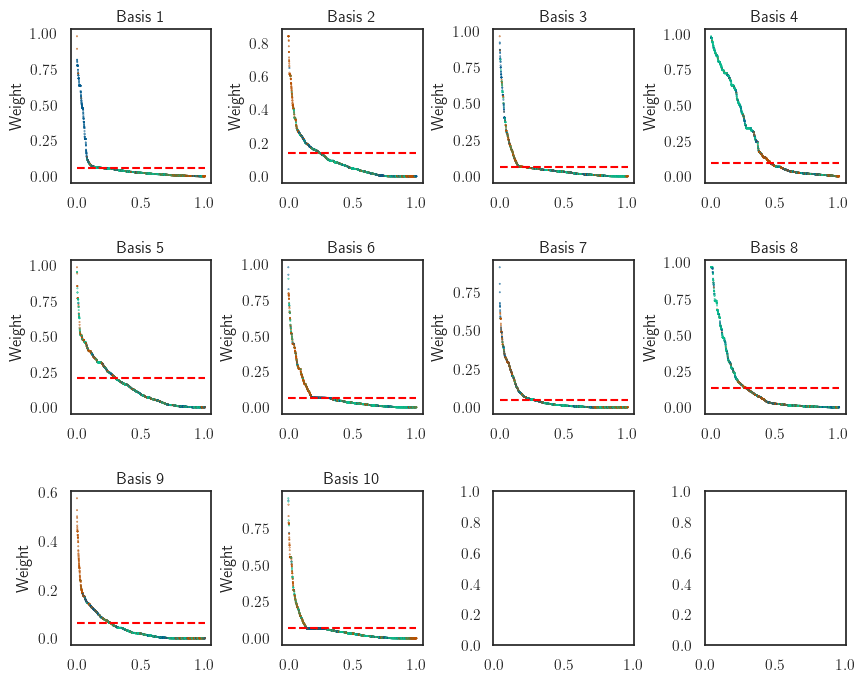

[    2     4     8 ... 23771 23777 23786]
[0.055255063, 0.13975275, 0.060886793, 0.09434857, 0.2077952, 0.06637823, 0.050072215, 0.13079754, 0.06395816, 0.066668764]


In [29]:
# Since most patterns are close to 0 for most clones, we want to find a cutoff to filter out unimportant patterns. 
# We do not want to use an arbitrary cutoff, so we use the KneeLocator to find the elbow point of the fitted clone 
# scales and beta values. This will prevent the results from being skewed by unimportant patterns.
# Find the elbow points of the fitted clone scales and beta values


clone_scales_train = pd.DataFrame({"Clone Scales":clone_scales_a.squeeze()}) #Store clone scales in a DataFrame

#Combine beta and clone scales into a single DataFrame for plotting
beta_and_scale_df_a_comb_melt = pd.concat([beta_and_scale_df_a_comb, data_filt_a_train[["GVHD Grade", "PTCy", "cdr3_amino_acid"]], clone_scales_train], axis = 1).melt(id_vars=["GVHD Grade", "PTCy", "cdr3_amino_acid", "Clone Scales"])


colors = ["#09BB8C", "#005A8F", "#B85000"]

cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

cut_off = []
fig, axs = plt.subplots(3,4, figsize = (10,8), gridspec_kw = {"wspace":0.5, "hspace":0.5})
axs = axs.flatten()

beta_and_scale_df_a_comb_melt["GVHD Color"] = beta_and_scale_df_a_comb_melt["GVHD Grade"].map({"No":0, "Mild":1, "Severe":2})
beta_and_scale_df_a_comb_melt["GVHD Color"] = beta_and_scale_df_a_comb_melt["GVHD Grade"].map({"No":0, "Mild":1, "Severe":2})

keep_idx = np.empty(0, dtype = int)
for idx, b in enumerate(beta_and_scale_df_a_comb_melt["variable"].unique()):
    #Select Basis
    beta_and_scale_df_a_comb_melt_sel = beta_and_scale_df_a_comb_melt[(beta_and_scale_df_a_comb_melt["variable"] == b)].sort_values(by = "value", ascending = False).reset_index().reset_index()
    
    #Locate elbow/knee point
    kn = KneeLocator(range(0,len(beta_and_scale_df_a_comb_melt_sel)),beta_and_scale_df_a_comb_melt_sel.sort_values(by = "value", ascending = False)['value'].values, curve='convex', direction='decreasing', S= 10, interp_method="polynomial", polynomial_degree = 4)
    patient_cut_off = beta_and_scale_df_a_comb_melt_sel.sort_values(by = "value", ascending = False)['value'].values[kn.knee]
    cut_off.append(patient_cut_off) #store cutoff
    
    beta_and_scale_df_a_comb_melt_sel["x_norm"] = np.linspace(0,1,beta_and_scale_df_a_comb_melt_sel.shape[0])#Create cutoff line
    
    #Plot the results
    axs[idx].scatter(beta_and_scale_df_a_comb_melt_sel["x_norm"].values, beta_and_scale_df_a_comb_melt_sel["value"].values, c = beta_and_scale_df_a_comb_melt_sel["GVHD Color"].values, cmap = cmap , s = 0.1)
    axs[idx].hlines(cut_off[idx], xmin = 0, xmax = 1, color = "red", linestyle = "--")
    axs[idx].set_title("Basis {}".format(b))
    axs[idx].set_ylabel("Weight")
    
    #Store samples to keep for analysis
    keep_idx = np.append(keep_idx, beta_and_scale_df_a_comb_melt_sel[beta_and_scale_df_a_comb_melt_sel["value"] > patient_cut_off]["index"])

#Uncomment to save figures
plt.savefig("../FigureOutput/Final_Output/CutPointFilter.png", dpi = 600, bbox_inches='tight')
plt.savefig("../FigureOutput/Final_Output/CutPointFilter.pdf", dpi = 600, bbox_inches='tight')

plt.show()
keep_idx = np.unique(keep_idx)
print(keep_idx)
print(cut_off)

In [30]:
beta_and_scale_df_a_comb_melt_filt = beta_and_scale_df_a_comb_melt.loc[keep_idx,:] #filter the DataFrame to only keep the samples above the cutoff

In [31]:
#Plot proportion of clones in each GVHD grade after filtering
pie_df = pd.DataFrame(beta_and_scale_df_a_comb_melt_filt.value_counts(subset = ["GVHD Grade", "variable"])).reset_index().sort_values(["variable", "GVHD Grade"])

# fig, axs = plt.subplots(3,4, figsize = (20, 6))
axs = axs.flatten()
colors = ["#09BB8C", "#005A8F", "#B85000"]

#Uncomment below to visualize class proportions after filtering
# for idx, ax in enumerate(axs):
#     if len(pie_df.loc[pie_df["variable"] == idx + 1]) == 0:
#         ax.axis('off')
#     else:
#         ax.pie(pie_df.loc[pie_df["variable"] == idx + 1, "count"], labels = pie_df.loc[pie_df["variable"] == idx + 1, "GVHD Grade"], colors = colors, autopct='%1.2f%%')
#         if isinstance(b, (int, float)):
#             ax.set_title("Basis {}".format(b))
#         else:
#             ax.set_title("{}".format(b))

#Uncomment to save figures
# plt.savefig("../FigureOutput/Final_Output/ProportionAfterFilter.png", dpi = 600, bbox_inches='tight')
# plt.savefig("../FigureOutput/Final_Output/ProportionAfterFilter.pdf", dpi = 600, bbox_inches='tight')
# plt.show()



In [32]:
pie_perc  = pie_df.pivot_table(index = "GVHD Grade", columns = "variable", values = "count").apply(lambda x: x/np.sum(x), axis = 0).reset_index().melt(id_vars = "GVHD Grade", var_name = "Basis", value_name = "prop")
pie_perc["sig_prop"] = pie_perc["prop"] > 1/3 #Set true if the proportion is greater than 1/3

/var/folders/gx/mj33d0l133360qcq8lp1qyhw0000gn/T/ipykernel_67236/1410586315.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pie_perc  = pie_df.pivot_table(index = "GVHD Grade", columns = "variable", values = "count").apply(lambda x: x/np.sum(x), axis = 0).reset_index().melt(id_vars = "GVHD Grade", var_name = "Basis", value_name = "prop")


In [33]:
from scipy.stats import mannwhitneyu
import statsmodels
import statsmodels.stats
import statsmodels.stats.multitest

#Perform Mann-Whitney U test between different GVHD grades for each basis function and their weights

beta_train_df = beta_and_scale_df_a_comb_melt_filt.copy().reset_index()
beta_train_df = beta_train_df.pivot_table(index = ["index", "GVHD Grade", "GVHD Color"], values = ["value"], columns = ["variable"])
beta_train_df.columns = beta_train_df.columns.get_level_values(1)
beta_train_df = beta_train_df.reset_index().drop("index", axis = 1)



all_res = {"pvalue": [], "GVHD Grade":[], "GVHD Grade 2":[], "Basis":[]}
for grade_1 in ["No", "Mild", "Severe"]:
    for grade_2 in ["No", "Mild", "Severe"]:
        if grade_1 != grade_2:
            for i in range(1,beta_and_scale_df_a_comb.shape[1]+1,1):
                x = beta_train_df.loc[beta_train_df["GVHD Grade"] == grade_1].dropna(subset = i)
                y = beta_train_df.loc[beta_train_df["GVHD Grade"] == grade_2].dropna(subset = i)
                all_res["pvalue"].append(mannwhitneyu(x = x[i].values, y =  y[i].values, alternative ='greater').pvalue)
                all_res["GVHD Grade"].append(grade_1)
                all_res["GVHD Grade 2"].append(grade_2)
                all_res["Basis"].append(i)

all_res = pd.DataFrame(all_res)
all_res_adj = all_res.copy()
all_res_adj.pvalue = statsmodels.stats.multitest.multipletests(all_res.pvalue, method = "fdr_bh")[1]
all_res_adj = all_res_adj.merge(pie_perc, on = ["GVHD Grade", "Basis"])
all_res = pd.pivot_table(all_res, values = "pvalue", index = ["GVHD Grade", "GVHD Grade 2"],columns = ["Basis"])
    
all_res
all_res_adj[(all_res_adj.pvalue < 0.05) & all_res_adj["sig_prop"]].sort_values(by = "Basis")
    

/var/folders/gx/mj33d0l133360qcq8lp1qyhw0000gn/T/ipykernel_67236/704963310.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  beta_train_df = beta_train_df.pivot_table(index = ["index", "GVHD Grade", "GVHD Color"], values = ["value"], columns = ["variable"])


,pvalue,GVHD Grade,GVHD Grade 2,Basis,prop,sig_prop
20,1.012868e-34,Mild,No,1,0.508571,True
30,4.211499e-20,Mild,Severe,1,0.508571,True
41,7.982615e-11,Severe,No,2,0.439316,True
51,4.527258e-15,Severe,Mild,2,0.439316,True
3,2.947195e-15,No,Mild,4,0.626134,True
13,3.118536e-89,No,Severe,4,0.626134,True
4,1.293127e-08,No,Mild,5,0.390516,True
54,4.425732e-07,Severe,Mild,5,0.439331,True
55,6.317295e-31,Severe,Mild,6,0.673835,True
46,7.487703e-09,Severe,No,7,0.456706,True


In [34]:
all_res_adj_filt = all_res_adj[(all_res_adj.pvalue < 0.05) & all_res_adj["sig_prop"]].sort_values(by = "Basis")
count_signif = pd.DataFrame(all_res_adj_filt.value_counts(subset = ["GVHD Grade", "Basis"]))
count_signif = count_signif[count_signif["count"] > 1].reset_index().sort_values(["GVHD Grade", "Basis"])
count_signif["Basis"] = count_signif["Basis"].astype(str)
count_signif

,GVHD Grade,Basis,count
0,Mild,1,2
1,No,4,2
2,No,8,2
3,Severe,2,2
4,Severe,7,2
5,Severe,9,2


In [35]:
from statannotations.Annotator import Annotator
plt.rcParams.update({'text.usetex': False})  # Disable LaTeX rendering
%matplotlib inline

#Set theme and figure size
sns.set_theme(style="white", rc={"axes.spines.right": False, "axes.spines.top": False, "figure.dpi": 600, 'font.size': 24, "xtick.labelsize":24, "ytick.labelsize":24})
fig, axs = plt.subplots(1,3, figsize=(30,6), dpi = 600, sharey = True)

#Prepare DataFrame for plotting
beta_train_df = beta_and_scale_df_a_comb_melt_filt.copy().reset_index()
beta_train_df = beta_train_df.pivot_table(index = ["index", "GVHD Grade", "GVHD Color"], values = ["value"], columns = ["variable"])
beta_train_df.columns = beta_train_df.columns.get_level_values(1).astype(str)
beta_train_df = beta_train_df.reset_index().drop("index", axis = 1)


all_res_adj["Basis"] = all_res_adj["Basis"].astype(str)


# NO
order = count_signif.loc[count_signif["GVHD Grade"] == "No", "Basis"].values

beta_train_df_sel = beta_train_df[np.append("GVHD Grade", order)]
all_res_sel = all_res_adj[all_res_adj["Basis"].isin(order)].reset_index(drop = True)

#Get pairs for annotation
pairs = []
for i in range(len(all_res_sel)):
     pairs.append(((all_res_sel["Basis"][i], all_res_sel["GVHD Grade"][i]),(all_res_sel["Basis"][i], all_res_sel["GVHD Grade 2"][i])))



beta_train_df_melt_sel = beta_train_df_sel.melt(id_vars = ['GVHD Grade'])
beta_train_df_melt_sel.columns = beta_train_df_melt_sel.columns.str.strip()

df = beta_train_df_melt_sel


x = "variable"
y = "value"
hue = "GVHD Grade"
hue_order=['No', 'Mild', 'Severe']
axs[0] = sns.violinplot(ax = axs[0], data=df, x=x, y=y, order=order, hue=hue, hue_order=hue_order, palette = sns.color_palette(["#09BB8C", "#005A8F", "#B85000"]))
sns.stripplot(data=df, x=x, y=y, color="k", hue = hue, size=3, ax=axs[0], dodge = True)
axs[0].legend_.remove()
axs[0].set_xlabel("Basis", fontsize = 24)
axs[0].set_ylabel("Basis Weight", fontsize = 24)
axs[0].set_title("No", fontsize = 24)
annot = Annotator(axs[0] , pairs, data=df, x=x, y=y, order=order, hue=hue, hue_order=hue_order)
annot.configure(test=None, test_short_name="manual", verbose = 2, hide_non_significant = True, line_offset = 2, line_offset_to_group = 0,)
annot.set_pvalues(pvalues=all_res_sel["pvalue"])
annot.annotate()
plt.legend(loc='upper left', bbox_to_anchor=(1.03, 1))


## Mild

order = count_signif.loc[count_signif["GVHD Grade"] == "Mild", "Basis"].values

beta_train_df_sel = beta_train_df[np.append(np.array(["GVHD Grade"]), order)]
all_res_sel = all_res_adj[all_res_adj["Basis"].isin(order)].reset_index(drop = True)


pairs = []
for i in range(len(all_res_sel)):
     pairs.append(((all_res_sel["Basis"][i], all_res_sel["GVHD Grade"][i]),(all_res_sel["Basis"][i], all_res_sel["GVHD Grade 2"][i])))


beta_train_df_melt_sel = beta_train_df_sel.melt(id_vars = ['GVHD Grade'])
beta_train_df_melt_sel = beta_train_df_melt_sel[beta_train_df_melt_sel["value"]>0.0]
beta_train_df_melt_sel.columns = beta_train_df_melt_sel.columns.str.strip()

df = beta_train_df_melt_sel


x = "variable"
y = "value"
hue = "GVHD Grade"
hue_order=['No', 'Mild', 'Severe']
axs[1]  = sns.violinplot(ax = axs[1], data=df, x=x, y=y, order=order, hue=hue, hue_order=hue_order, palette = sns.color_palette(["#09BB8C", "#005A8F", "#B85000"]))
sns.stripplot(data=df, x=x, y=y, color="k", hue = hue, size=3, ax=axs[1], dodge = True)
axs[1].legend_.remove()
axs[1].set_xlabel("Basis", fontsize = 24)
axs[1].set_ylabel("", fontsize = 24)
axs[1].set_title("Mild", fontsize = 24)
annot = Annotator(axs[1] , pairs, data=df, x=x, y=y, order=order, hue=hue, hue_order=hue_order,)
annot.configure(test=None, test_short_name="manual", verbose = 2, hide_non_significant = True, line_offset = 2, line_offset_to_group = 0)
annot.set_pvalues(pvalues=all_res_sel["pvalue"])
annot.annotate()
plt.legend(loc='upper left', bbox_to_anchor=(1.03, 1))


## Severe
order = count_signif.loc[count_signif["GVHD Grade"] == "Severe", "Basis"].values

beta_train_df_sel = beta_train_df[np.append(np.array(["GVHD Grade"]), order)]
all_res_sel = all_res_adj[all_res_adj["Basis"].isin(order)].reset_index(drop = True)


pairs = []
for i in range(len(all_res_sel)):
     pairs.append(((all_res_sel["Basis"][i], all_res_sel["GVHD Grade"][i]),(all_res_sel["Basis"][i], all_res_sel["GVHD Grade 2"][i])))


beta_train_df_melt_sel = beta_train_df_sel.melt(id_vars = ['GVHD Grade'])
beta_train_df_melt_sel = beta_train_df_melt_sel[beta_train_df_melt_sel["value"]>0.0]
beta_train_df_melt_sel.columns = beta_train_df_melt_sel.columns.str.strip()

df = beta_train_df_melt_sel


x = "variable"
y = "value"
hue = "GVHD Grade"
hue_order=['No', 'Mild', 'Severe']
axs[2]  = sns.violinplot(ax = axs[2], data=df, x=x, y=y, order=order, hue=hue, hue_order=hue_order, palette = sns.color_palette(["#09BB8C", "#005A8F", "#B85000"]))
sns.stripplot(data=df, x=x, y=y, color="k", hue = hue, size=3, ax=axs[2], dodge = True)
axs[2].set_xlabel("Basis", fontsize = 24)
axs[2].set_ylabel("", fontsize = 24)
axs[2].set_title("Severe", fontsize = 24)
annot = Annotator(axs[2] , pairs, data=df, x=x, y=y, order=order, hue=hue, hue_order=hue_order)
annot.configure(test=None, test_short_name="manual", verbose = 2, hide_non_significant = True, line_offset = 2, line_offset_to_group = 0)
annot.set_pvalues(pvalues=all_res_sel["pvalue"])
annot.annotate()
plt.legend(loc='upper left', bbox_to_anchor=(1.03, 1))

#Uncomment to save figures
plt.savefig("../FigureOutput/Final_Output/SignifBasisWeightViolinPlot.png", dpi = 600, bbox_inches='tight')
plt.savefig("../FigureOutput/Final_Output/SignifBasisWeightViolinPlot.pdf", dpi = 600, bbox_inches='tight')

plt.show()


/var/folders/gx/mj33d0l133360qcq8lp1qyhw0000gn/T/ipykernel_67236/3282550156.py:11: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  beta_train_df = beta_train_df.pivot_table(index = ["index", "GVHD Grade", "GVHD Color"], values = ["value"], columns = ["variable"])
2025-10-01 21:40:44,708 | INFO : Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-01 21:40:44,716 | INFO : Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-01 21:40:44,718 | INFO : Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

8_No vs. 8_Mild: Custom statistical test, P_val:6.606e-03
8_Mild vs. 8_Severe: Custom statistical test, P_val:1.980e-17
4_No vs. 4_Mild: Custom statistical test, P_val:2.947e-15


/var/folders/gx/mj33d0l133360qcq8lp1qyhw0000gn/T/ipykernel_67236/3282550156.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left', bbox_to_anchor=(1.03, 1))
2025-10-01 21:40:45,274 | INFO : Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-01 21:40:45,277 | INFO : Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-01 21:40:45,278 | INFO : Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


4_Mild vs. 4_Severe: Custom statistical test, P_val:2.869e-38
8_No vs. 8_Severe: Custom statistical test, P_val:1.036e-39
4_No vs. 4_Severe: Custom statistical test, P_val:3.119e-89


2025-10-01 21:40:45,293 | INFO : Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/var/folders/gx/mj33d0l133360qcq8lp1qyhw0000gn/T/ipykernel_67236/3282550156.py:80: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(data=df, x=x, y=y, color="k", hue = hue, size=3, ax=axs[1], dodge = True)
2025-10-01 21:40:45,296 | INFO : Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/var/folders/gx/mj33d0l133360qcq8lp1qyhw0000gn/T/ipykernel_67236/3282550156.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is calle

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1_No vs. 1_Mild: Custom statistical test, P_val:1.013e-34
1_Mild vs. 1_Severe: Custom statistical test, P_val:4.211e-20


/var/folders/gx/mj33d0l133360qcq8lp1qyhw0000gn/T/ipykernel_67236/3282550156.py:116: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  sns.stripplot(data=df, x=x, y=y, color="k", hue = hue, size=3, ax=axs[2], dodge = True)
2025-10-01 21:40:45,530 | INFO : Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

9_No vs. 9_Mild: Custom statistical test, P_val:1.138e-13
7_Mild vs. 7_Severe: Custom statistical test, P_val:3.833e-05
9_Mild vs. 9_Severe: Custom statistical test, P_val:6.833e-05
2_Mild vs. 2_Severe: Custom statistical test, P_val:4.527e-15
7_No vs. 7_Severe: Custom statistical test, P_val:7.488e-09
9_No vs. 9_Severe: Custom statistical test, P_val:2.140e-16
2_No vs. 2_Severe: Custom statistical test, P_val:7.983e-11


In [36]:
beta_and_scale_df_a_filt = pd.pivot_table(beta_and_scale_df_a_comb_melt_filt, values = "value",columns = "variable",index = ["cdr3_amino_acid", "GVHD Grade", "GVHD Color"]).reset_index()

/var/folders/gx/mj33d0l133360qcq8lp1qyhw0000gn/T/ipykernel_67236/1605326470.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  beta_and_scale_df_a_filt = pd.pivot_table(beta_and_scale_df_a_comb_melt_filt, values = "value",columns = "variable",index = ["cdr3_amino_acid", "GVHD Grade", "GVHD Color"]).reset_index()


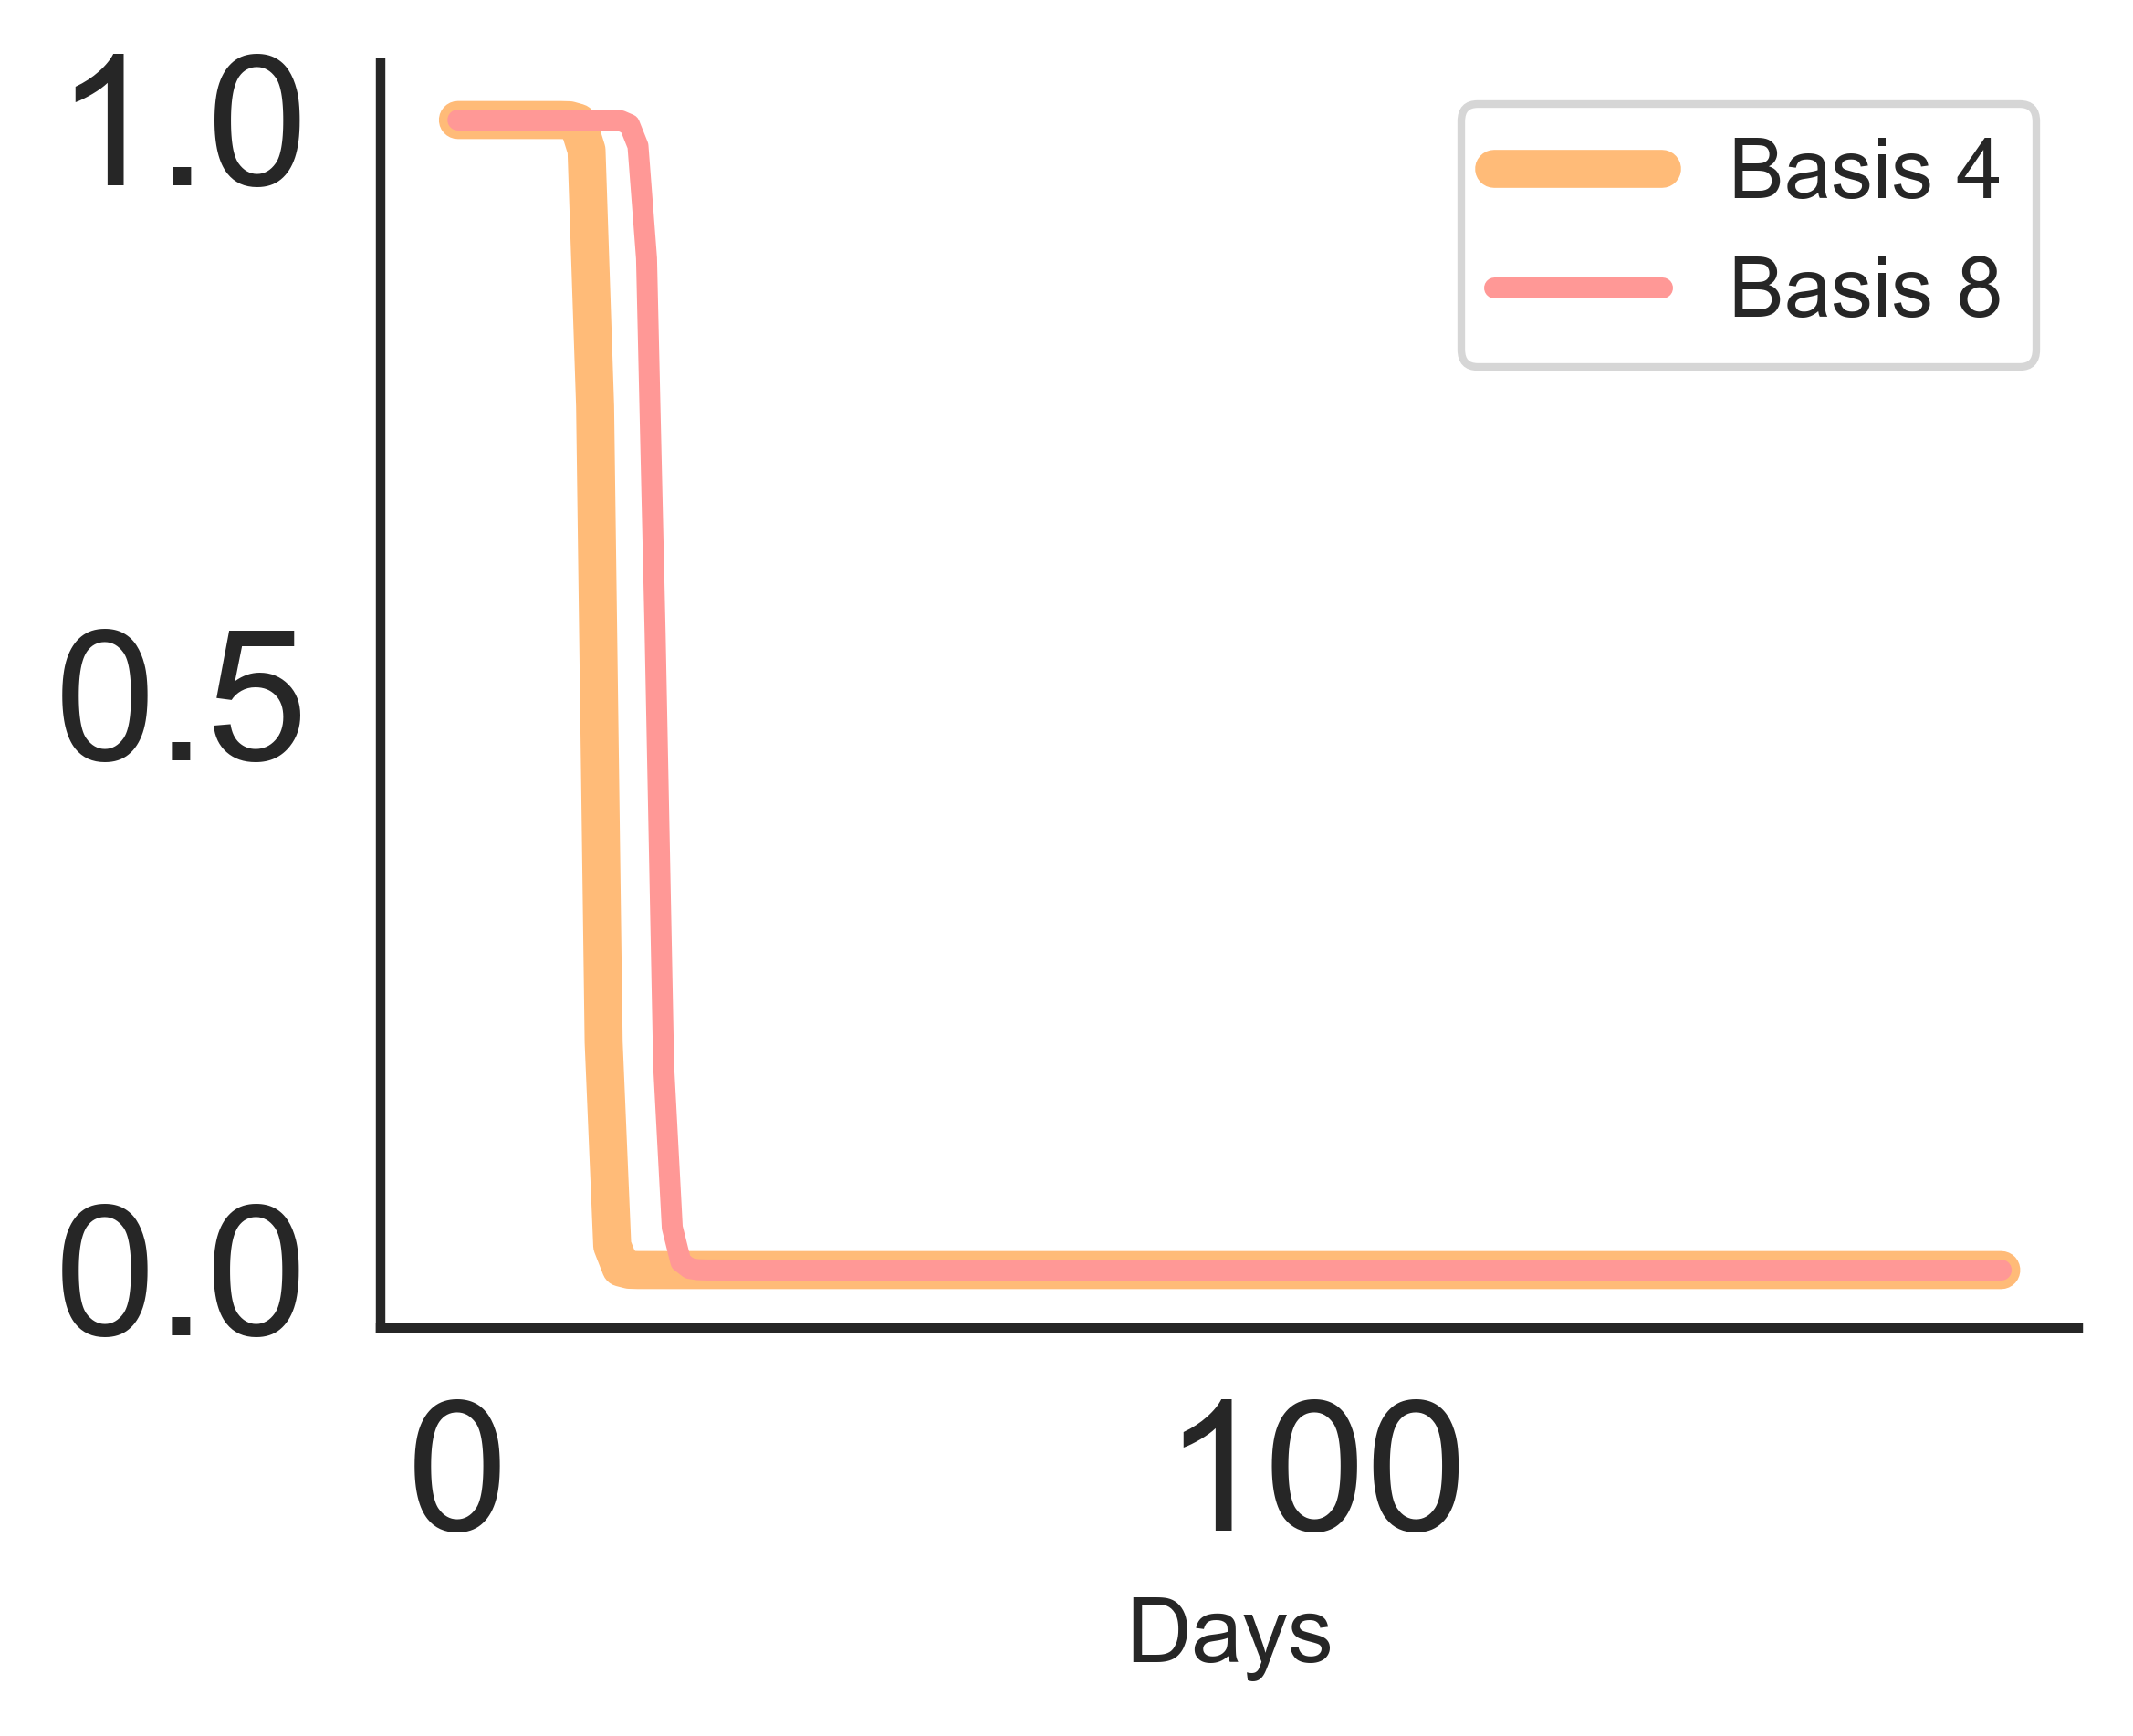

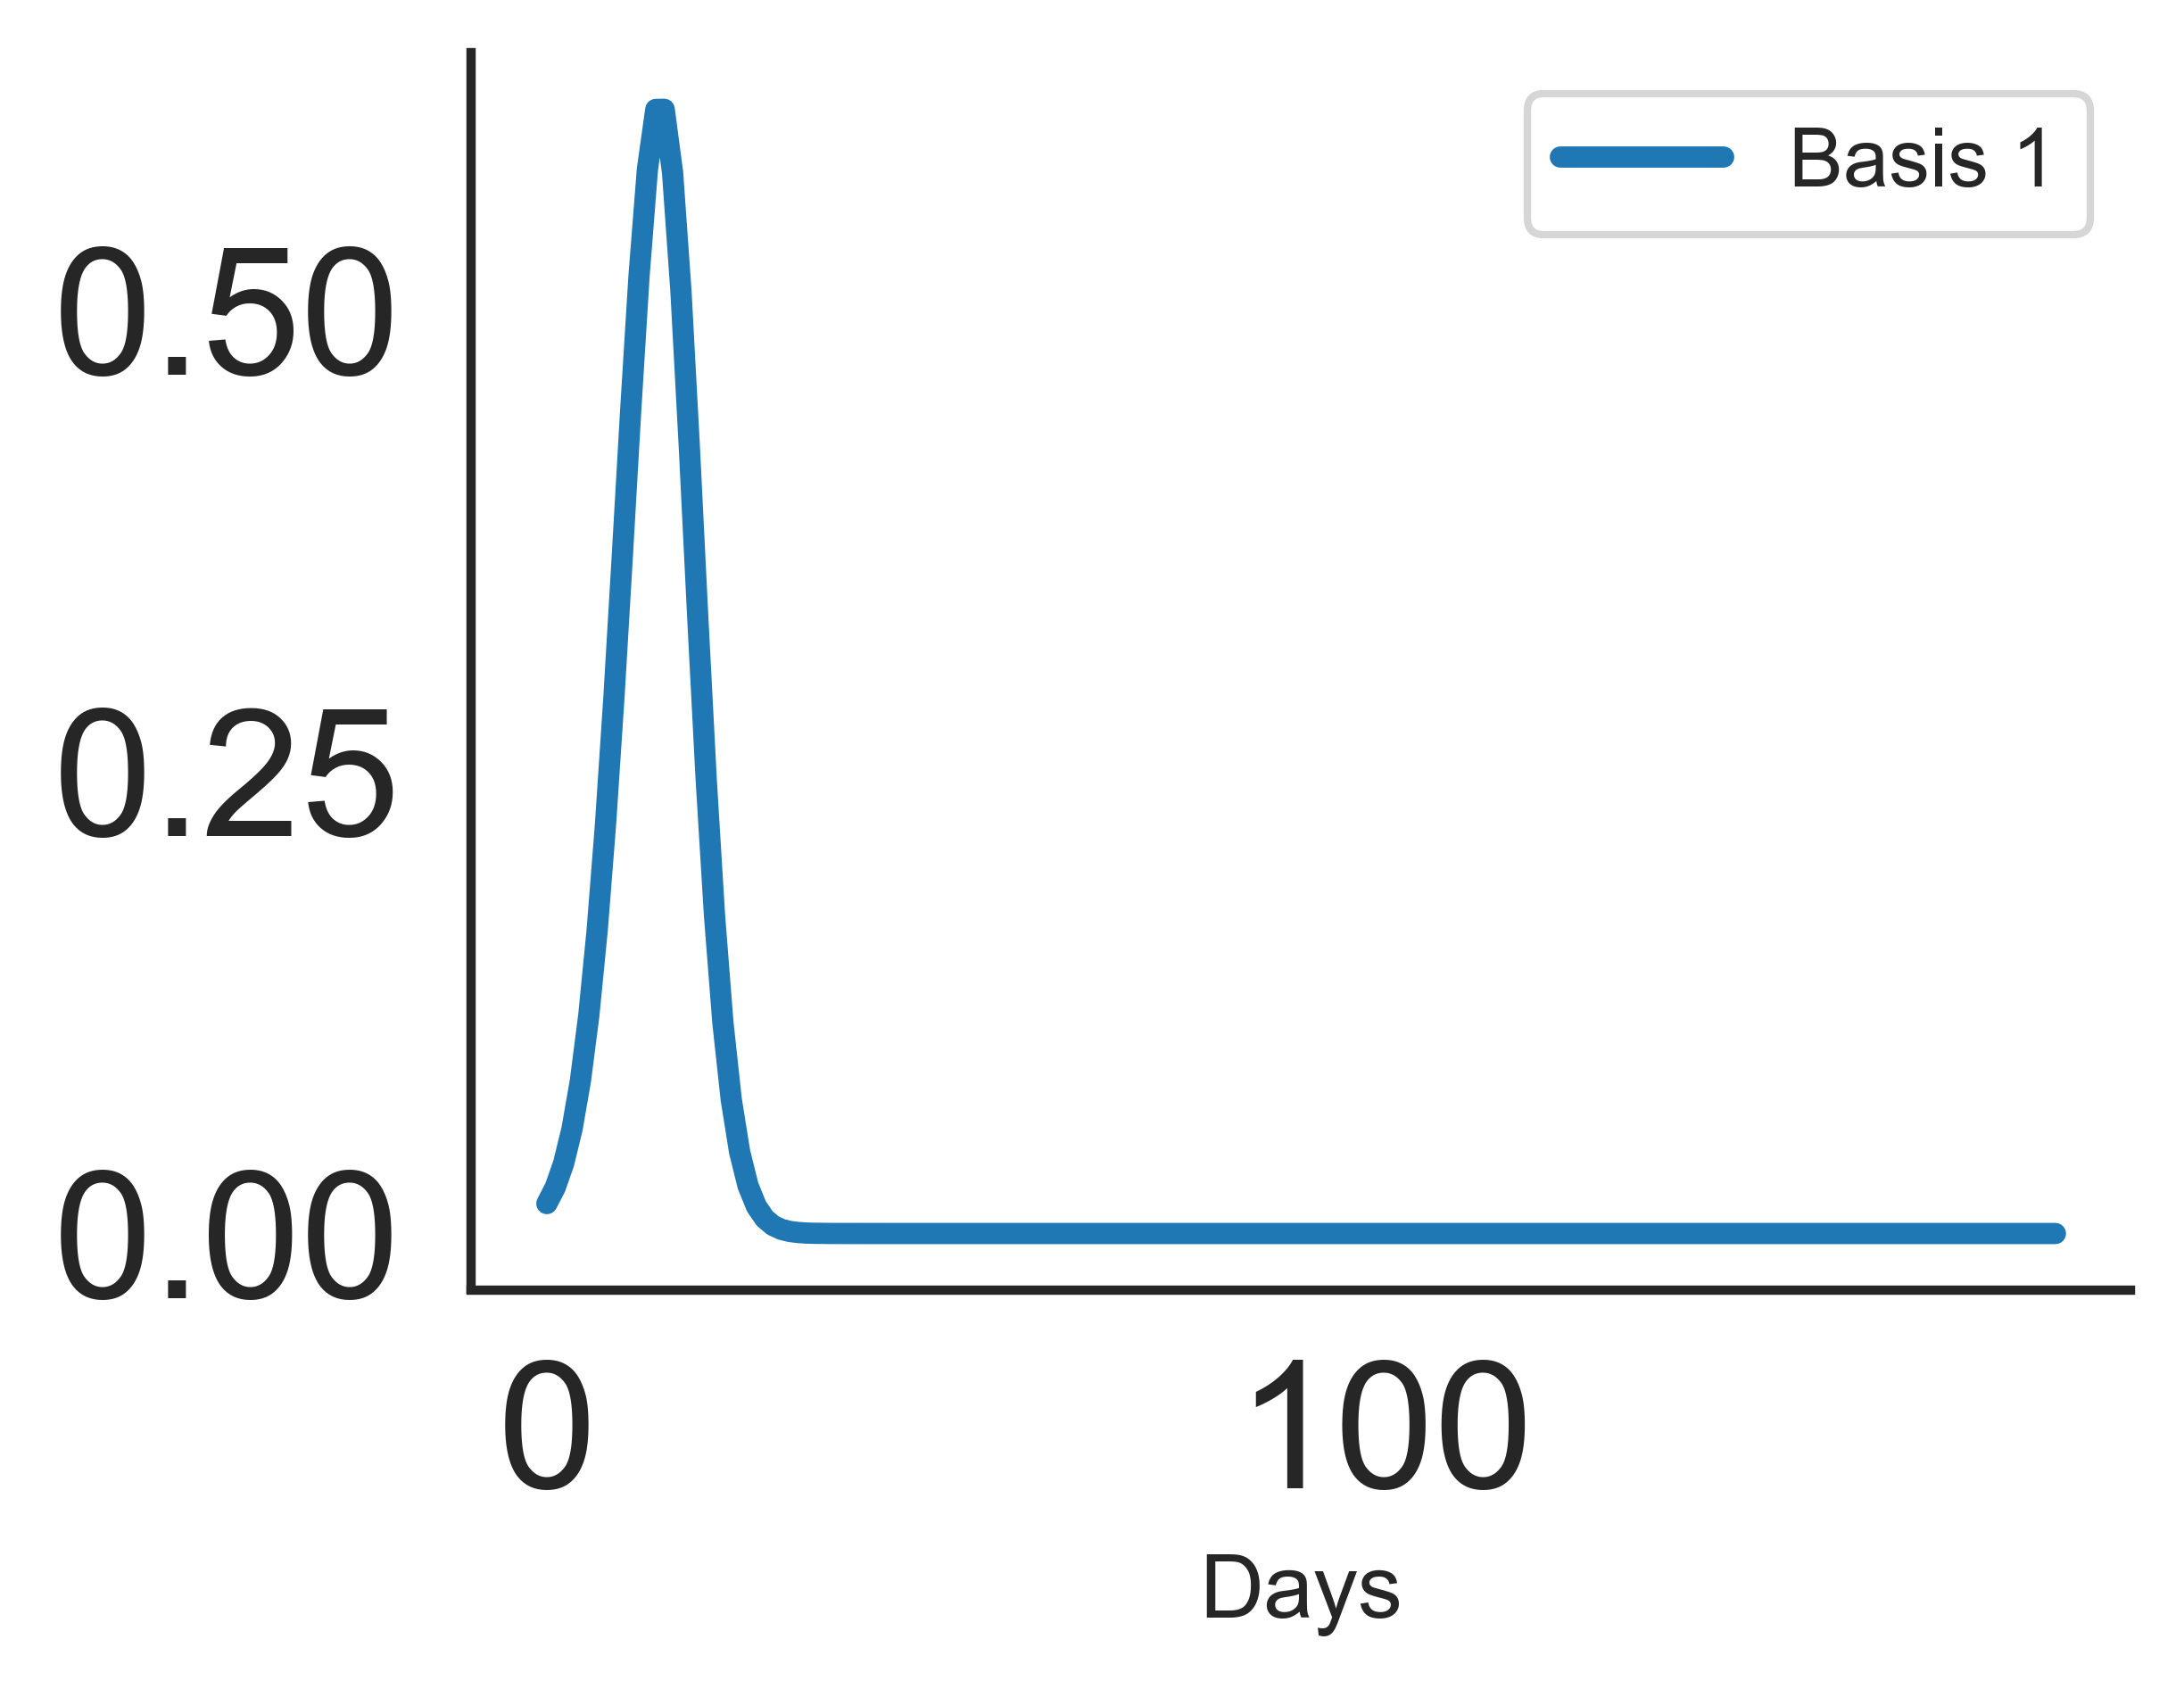

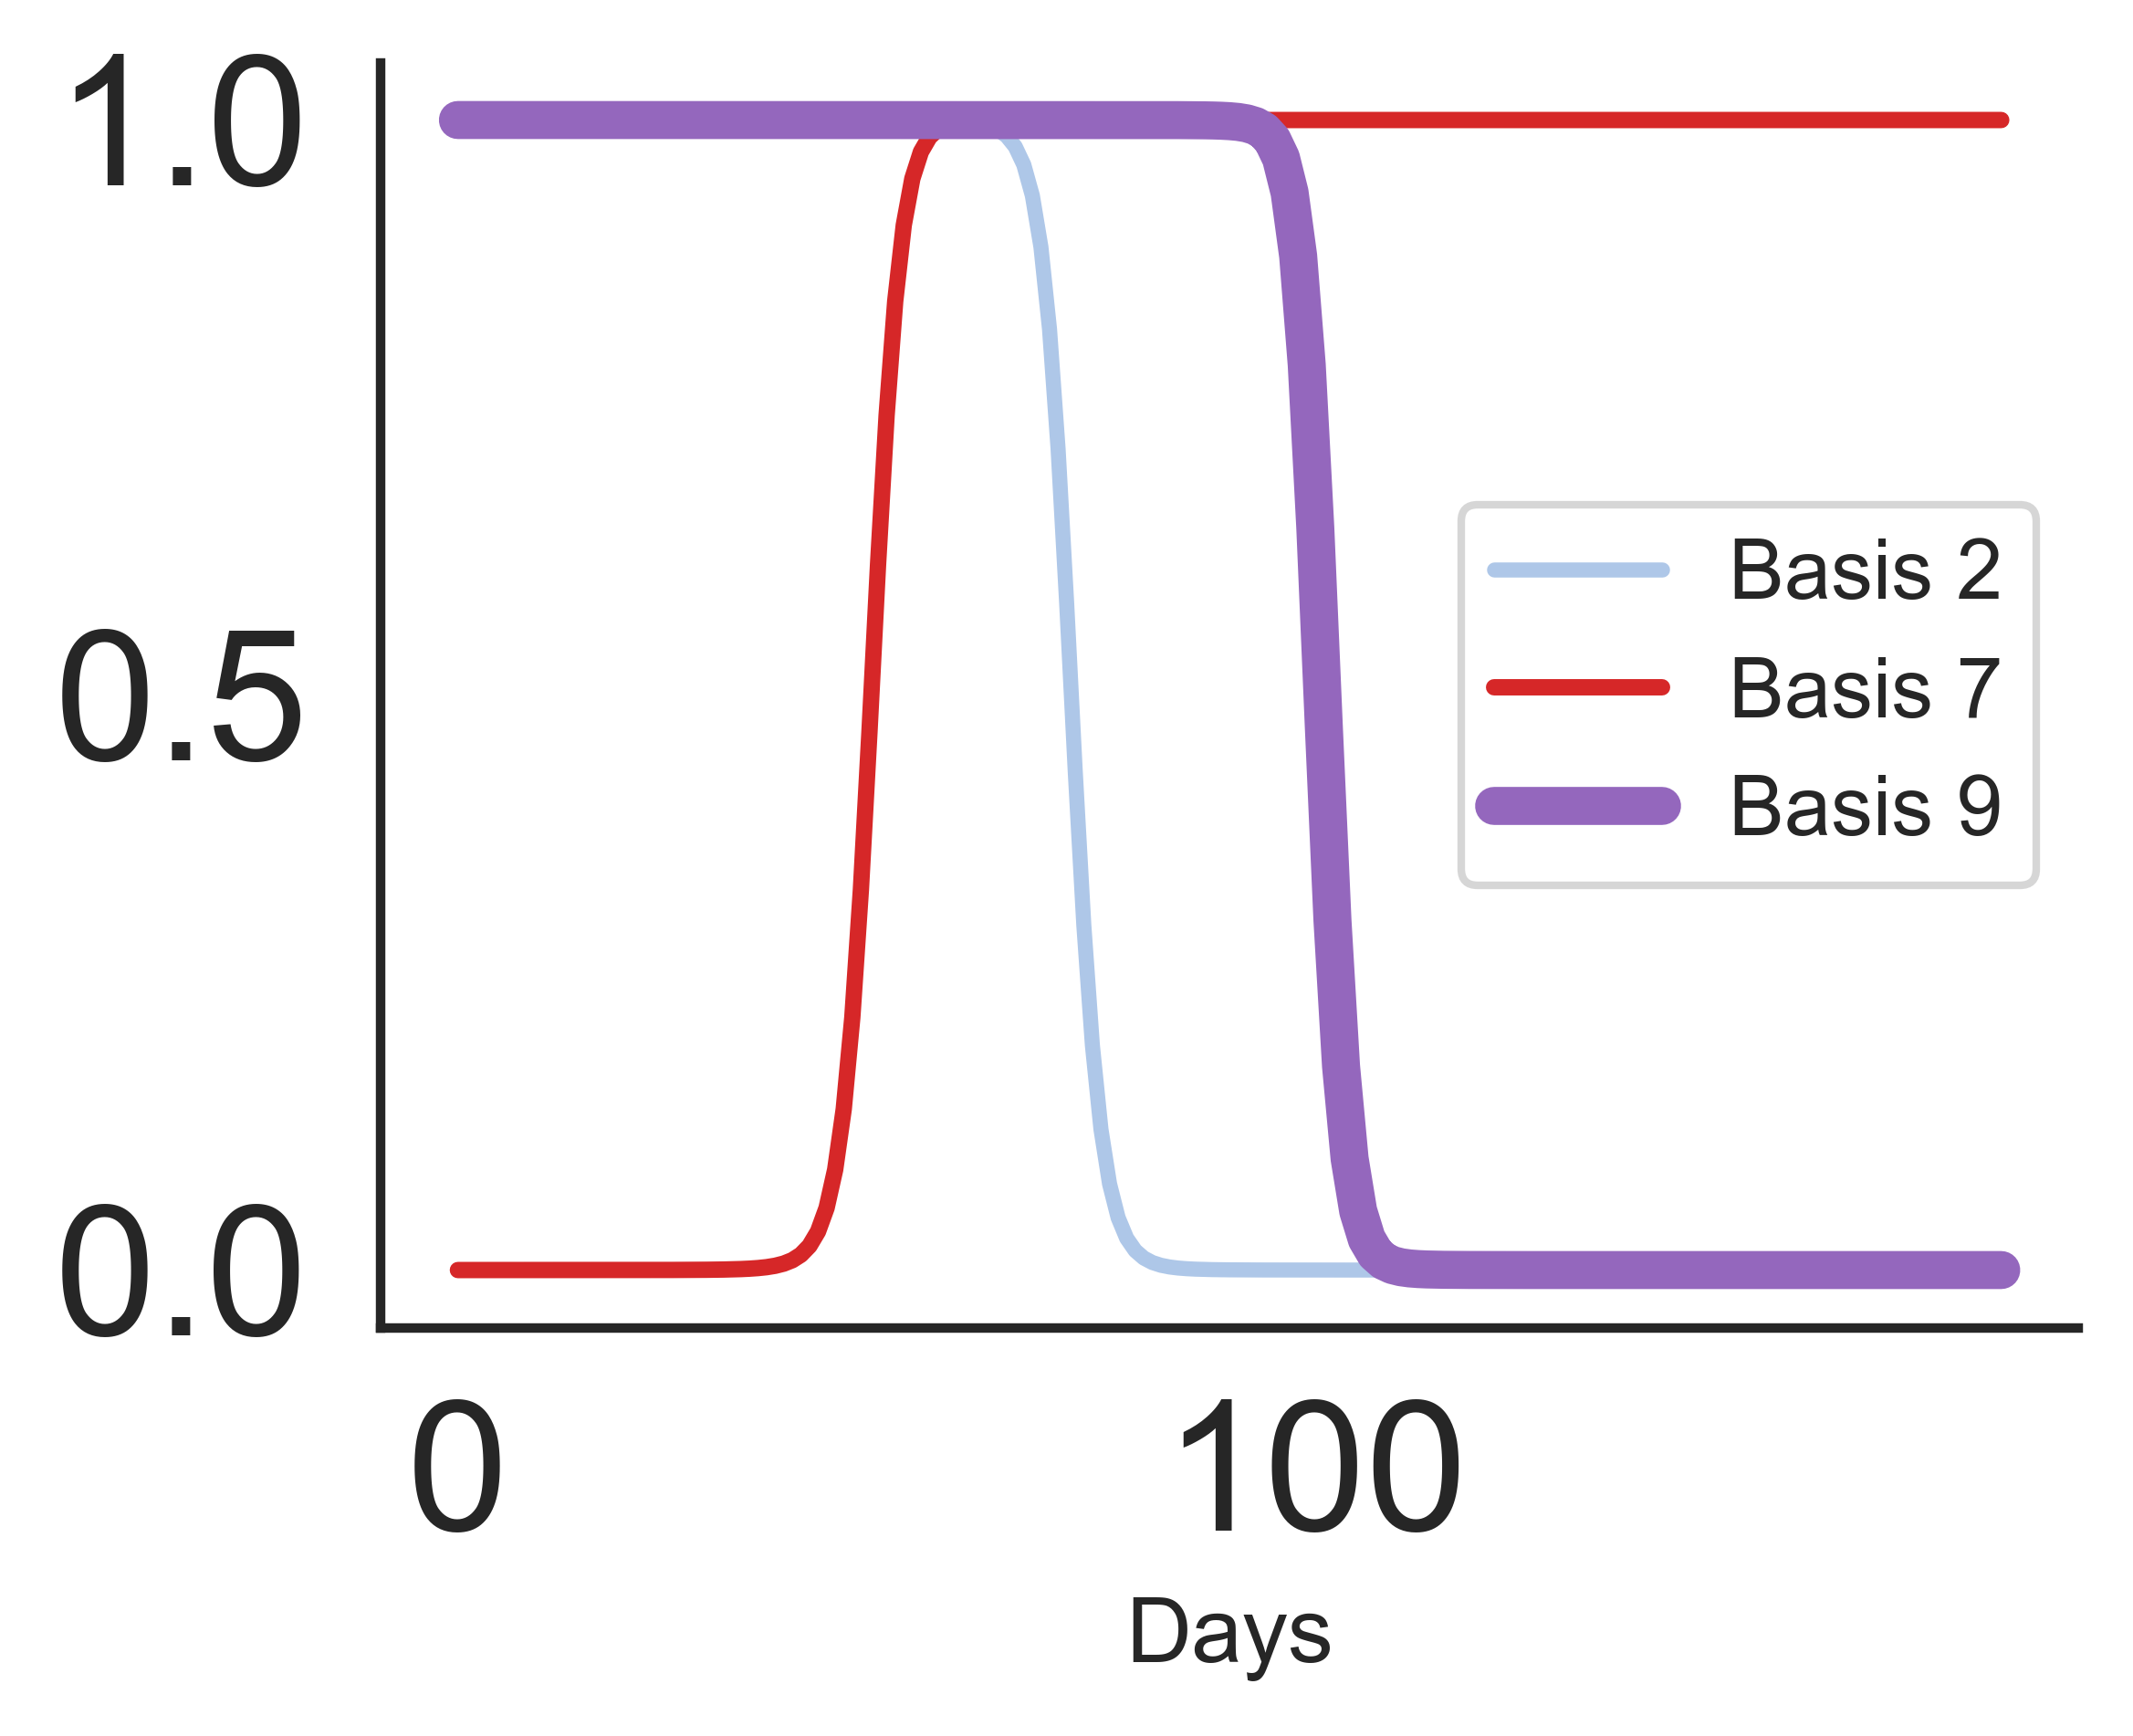

In [37]:
#Plot the weighted basis functions that are significant for each GVHD grade

line_width_No = beta_train_df.loc[beta_train_df["GVHD Grade"] == "No"].drop("GVHD Grade", axis = 1).apply(np.nanmean).values.reshape(-1,1)
line_width_Mild = beta_train_df.loc[beta_train_df["GVHD Grade"] == "Mild"].drop("GVHD Grade", axis = 1).apply(np.nanmean).values.reshape(-1,1)
line_width_Severe  = beta_train_df.loc[beta_train_df["GVHD Grade"] == "Severe"].drop("GVHD Grade", axis = 1).apply(np.nanmean).values.reshape(-1,1)

line_width = pd.DataFrame(np.concatenate((line_width_No, line_width_Mild, line_width_Severe), axis = 1)).T
line_width = line_width/line_width.max()*5

line_width.columns = beta_train_df.columns.values[:-1] 

palette = sns.color_palette("tab20", n_colors = n_basis)

#Plot the significant basis functions for each GVHD grade

#Uncomment below to change line styles and end of plot function
# ls = ["-.", "--", ":"]

#No
imp_basis = count_signif.loc[count_signif["GVHD Grade"] == "No", "Basis"].values
fig, ax = plt.subplots(1,1, figsize = (4,3), dpi = 600)
for idx, b in enumerate(imp_basis):
    plt.plot(basis_a_comb[:,int(b)-1], linewidth = line_width.loc[0,b], c = palette[int(b)-1])#, linestyle = ls[idx%3])
legend_basis = ["Basis " + i for i in imp_basis]
plt.legend(legend_basis)
plt.xlabel("Days")

#Uncomment to save figures
plt.savefig("../FigureOutput/Final_Output/SignifBasisLinePlot_No.png",dpi=600, bbox_inches = "tight")
plt.savefig("../FigureOutput/Final_Output/SignifBasisLinePlot_No.pdf",dpi=600, bbox_inches = "tight")


#Mild
imp_basis = count_signif.loc[count_signif["GVHD Grade"] == "Mild", "Basis"].values
fig, ax = plt.subplots(1,1, figsize = (4,3), dpi = 600)
for idx, b in enumerate(imp_basis):
    plt.plot(basis_a_comb[:,int(b)-1], linewidth = line_width.loc[1,b], c = palette[int(b)-1])#,linestyle = ls[idx%3])
legend_basis = ["Basis " + i for i in imp_basis]
plt.legend(legend_basis)
plt.xlabel("Days")

#Uncomment to save figures
plt.savefig("../FigureOutput/Final_Output/SignifBasisLinePlot_Mild.png",dpi=600, bbox_inches = "tight")
plt.savefig("../FigureOutput/Final_Output/SignifBasisLinePlot_Mild.pdf",dpi=600, bbox_inches = "tight")

#Severe
imp_basis = count_signif.loc[count_signif["GVHD Grade"] == "Severe", "Basis"].values
fig, ax = plt.subplots(1,1, figsize = (4,3), dpi = 600)
for idx, b in enumerate(imp_basis):
    plt.plot(basis_a_comb[:,int(b)-1], linewidth = line_width.loc[2,b], c = palette[int(b)-1])#, linestyle = ls[idx%3])
legend_basis = ["Basis " + i for i in imp_basis]
plt.legend(legend_basis)
plt.xlabel("Days")
plt.savefig("../FigureOutput/Final_Output/SignifBasisLinePlot_Severe.png",dpi=600, bbox_inches = "tight")
plt.savefig("../FigureOutput/Final_Output/SignifBasisLinePlot_Severe.pdf",dpi=600, bbox_inches = "tight")